# YOLOv8 для виявлення цілі з дрона — прокачаний ноутбук

Цей ноутбук не просто запускає навчання, а перед ним робить **аудит датасету**:

1. перевіряє структуру `train/images`, `val/images`, `train/labels`, `val/labels`;
2. створює `dataset.yaml`;
3. перевіряє YOLO-розмітку;
4. рахує порожні кадри, bbox, класи, розміри об'єктів;
5. шукає підозрілі бокси: дуже малі, дуже великі, біля країв, у HUD-зонах;
6. перевіряє можливий leakage між `train` і `val` через схожі кадри;
7. тренує YOLO з параметрами, кращими для дрібної IR/монохромної цілі;
8. робить валідацію і prediction-прев'ю.

> Шляхи нижче налаштовані відносно папки ноутбука.


## 0. Встановлення пакетів


```bash
python -m pip install -U ultralytics pyyaml matplotlib opencv-python pandas tqdm
```


In [1]:
%pip install -U ultralytics pyyaml matplotlib opencv-python pandas tqdm
print("Пакети встановлені або вже доступні.")


Note: you may need to restart the kernel to use updated packages.
Пакети встановлені або вже доступні.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import os
import math
import json
import random
import shutil
from collections import Counter, defaultdict

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import Image, display

from ultralytics import YOLO

print("Імпорти готові.")


c:\Users\sasha\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Імпорти готові.


## 1. Налаштування

Це має бути папка, де вже є `train/images`, `val/images`, `train/labels`, `val/labels`.


In [3]:
# =========================
# ОСНОВНІ ШЛЯХИ
# =========================

from pathlib import Path
import random
import numpy as np

# Папка датасету поруч із ноутбуком:
# yolo_split/train/images
# yolo_split/train/labels
# yolo_split/val/images
# yolo_split/val/labels
YOLO_SPLIT_DIR = Path.cwd() / "yolo_split"

# Де зберігати результати навчання
PROJECT_DIR = Path.cwd() / "runs"

# Назва запуску
RUN_NAME = "target_detector_cpu_test"

# Класи
CLASS_NAMES = {0: "target"}

# =========================
# МОДЕЛЬ І НАВЧАННЯ
# =========================

# CPU-режим, бо CUDA зараз недоступна
BASE_MODEL = "yolov8n.pt"
IMGSZ = 640
EPOCHS = 30
BATCH = 2
DEVICE = 0

# Для Windows/Jupyter краще 0, щоб не падав DataLoader
WORKERS = 0

SEED = 42

# =========================
# АУДИТ ДАТАСЕТУ
# =========================

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Межі для аналізу bbox
TINY_BOX_AREA = 0.00003
SMALL_BOX_AREA = 0.00025
HUGE_BOX_AREA = 0.25
EDGE_MARGIN = 0.03

# HUD-зони. Координати нормалізовані: x1, y1, x2, y2
HUD_ZONES = [
    (0.00, 0.00, 1.00, 0.12),
    (0.00, 0.88, 1.00, 1.00),
    (0.00, 0.00, 0.16, 1.00),
    (0.84, 0.00, 1.00, 1.00),
]

# Перевірку схожих кадрів поки вимикаємо, щоб не гальмувало на CPU
RUN_LEAKAGE_CHECK = False
MAX_IMAGES_FOR_LEAKAGE = 1200
LEAKAGE_HASH_DISTANCE = 3

# Відео для тестового prediction, якщо потрібно
RUN_VIDEO_PREDICT = False
VIDEO_PATH = Path.cwd() / "test_video.mp4"

random.seed(SEED)
np.random.seed(SEED)

print("YOLO_SPLIT_DIR:", YOLO_SPLIT_DIR)
print("PROJECT_DIR:", PROJECT_DIR)
print("DEVICE:", DEVICE)
print("BASE_MODEL:", BASE_MODEL)

YOLO_SPLIT_DIR: e:\Drone\VideoDetection\v 0.2\yolo_split
PROJECT_DIR: e:\Drone\VideoDetection\v 0.2\runs
DEVICE: 0
BASE_MODEL: yolov8n.pt


## 2. Перевірка структури датасету

Якщо тут буде `MISSING`, значить або шлях неправильний, або датасет ще не розділений на train/val.


In [4]:
def split_img_dir(split: str) -> Path:
    return YOLO_SPLIT_DIR / split / "images"


def split_lbl_dir(split: str) -> Path:
    return YOLO_SPLIT_DIR / split / "labels"


def list_images(folder: Path):
    if not folder.exists():
        return []
    return sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS])

def list_labels(folder: Path):
    if not folder.exists():
        return []
    return sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() == ".txt"])

required_dirs = [
    split_img_dir("train"),
    split_img_dir("val"),
    split_lbl_dir("train"),
    split_lbl_dir("val"),
]

optional_dirs = [
    split_img_dir("test"),
    split_lbl_dir("test"),
]

print("=== Обов'язкові папки ===")
missing = []
for p in required_dirs:
    ok = p.exists()
    print(f"{p} -> {'OK' if ok else 'MISSING'}")
    if not ok:
        missing.append(p)

print("\n=== Додаткові папки ===")
for p in optional_dirs:
    print(f"{p} -> {'OK' if p.exists() else 'OPTIONAL / NOT FOUND'}")

if missing:
    raise FileNotFoundError(
        "Не вистачає обов'язкових папок. Перевір YOLO_SPLIT_DIR або спочатку розділи датасет на train/val."
    )

print("\nСтруктура базово коректна.")


=== Обов'язкові папки ===
e:\Drone\VideoDetection\v 0.2\yolo_split\train\images -> OK
e:\Drone\VideoDetection\v 0.2\yolo_split\val\images -> OK
e:\Drone\VideoDetection\v 0.2\yolo_split\train\labels -> OK
e:\Drone\VideoDetection\v 0.2\yolo_split\val\labels -> OK

=== Додаткові папки ===
e:\Drone\VideoDetection\v 0.2\yolo_split\test\images -> OK
e:\Drone\VideoDetection\v 0.2\yolo_split\test\labels -> OK

Структура базово коректна.


In [5]:
summary_rows = []
for split in ["train", "val", "test"]:
    img_dir = split_img_dir(split)
    lbl_dir = split_lbl_dir(split)
    if img_dir.exists() or lbl_dir.exists():
        imgs = list_images(img_dir)
        lbls = list_labels(lbl_dir)
        summary_rows.append({"split": split, "images": len(imgs), "labels": len(lbls)})

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


,split,images,labels
0,train,31586,31586
1,val,14301,14301
2,test,0,0


## 3. Створення `dataset.yaml`

YOLO використовує цей файл, щоб знати, де лежать train/val/test і які є класи.


In [6]:
dataset_yaml_path = YOLO_SPLIT_DIR / "dataset.yaml"

dataset_dict = {
    "path": str(YOLO_SPLIT_DIR).replace("\\", "/"),
    "train": "train/images",
    "val": "val/images",
    "names": CLASS_NAMES,
}

if split_img_dir("test").exists() and split_lbl_dir("test").exists() and list_images(split_img_dir("test")):
    dataset_dict["test"] = "test/images"

with open(dataset_yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(dataset_dict, f, allow_unicode=True, sort_keys=False)

print("Створено/оновлено:", dataset_yaml_path)
print(dataset_yaml_path.read_text(encoding="utf-8"))


Створено/оновлено: e:\Drone\VideoDetection\v 0.2\yolo_split\dataset.yaml
path: e:/Drone/VideoDetection/v 0.2/yolo_split
train: train/images
val: val/images
names:
  0: target



## 4. Глибока перевірка YOLO-розмітки

Цей блок шукає проблеми, які часто псують навчання:

- немає label для картинки;
- label є, але картинки немає;
- неправильний формат рядка;
- клас не існує;
- координати не в межах `[0, 1]`;
- bbox занадто малий/великий;
- bbox потрапляє в HUD-зони;
- bbox біля країв кадру.


In [7]:
def parse_yolo_label(label_path: Path):
    """Повертає список об'єктів і список помилок."""
    objects = []
    errors = []
    text = label_path.read_text(encoding="utf-8", errors="ignore").strip()
    if not text:
        return objects, errors

    for line_no, line in enumerate(text.splitlines(), start=1):
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        if len(parts) != 5:
            errors.append({"file": label_path.name, "line": line_no, "error": "not_5_values", "text": line})
            continue
        try:
            cls_raw, x, y, w, h = parts
            cls = int(float(cls_raw))
            x, y, w, h = map(float, [x, y, w, h])
        except Exception:
            errors.append({"file": label_path.name, "line": line_no, "error": "cannot_parse", "text": line})
            continue

        if cls not in CLASS_NAMES:
            errors.append({"file": label_path.name, "line": line_no, "error": "unknown_class", "text": line})

        vals = [x, y, w, h]
        if not all(0 <= v <= 1 for v in vals):
            errors.append({"file": label_path.name, "line": line_no, "error": "coords_out_of_range", "text": line})

        if w <= 0 or h <= 0:
            errors.append({"file": label_path.name, "line": line_no, "error": "non_positive_size", "text": line})

        objects.append({
            "class": cls,
            "x": x,
            "y": y,
            "w": w,
            "h": h,
            "area": w * h,
            "line": line_no,
        })
    return objects, errors


def point_in_zone(x, y, zone):
    x1, y1, x2, y2 = zone
    return x1 <= x <= x2 and y1 <= y <= y2


def infer_group(path: Path):
    s = str(path).lower()
    name = path.name.lower()
    if "clean" in s or "clean" in name:
        return "clean"
    if "hud" in s or "hud" in name:
        return "hud"
    return "unknown"


def image_shape(path: Path):
    img = cv2.imread(str(path))
    if img is None:
        return None
    h, w = img.shape[:2]
    return w, h


def audit_split(split: str):
    img_dir = split_img_dir(split)
    lbl_dir = split_lbl_dir(split)

    images = list_images(img_dir)
    labels = list_labels(lbl_dir)
    img_by_stem = {p.stem: p for p in images}
    lbl_by_stem = {p.stem: p for p in labels}

    missing_labels = sorted(set(img_by_stem) - set(lbl_by_stem))
    orphan_labels = sorted(set(lbl_by_stem) - set(img_by_stem))

    rows = []
    obj_rows = []
    errors = []

    for stem, img_path in tqdm(img_by_stem.items(), desc=f"audit {split}"):
        lbl_path = lbl_by_stem.get(stem)
        objects = []
        label_errors = []
        if lbl_path is not None:
            objects, label_errors = parse_yolo_label(lbl_path)
            errors.extend([{**e, "split": split, "label_path": str(lbl_path)} for e in label_errors])

        shape = image_shape(img_path)
        img_w, img_h = shape if shape else (None, None)
        group = infer_group(img_path)

        rows.append({
            "split": split,
            "image": img_path.name,
            "stem": stem,
            "image_path": str(img_path),
            "label_path": str(lbl_path) if lbl_path else None,
            "has_label": lbl_path is not None,
            "objects": len(objects),
            "is_negative": len(objects) == 0,
            "width_px": img_w,
            "height_px": img_h,
            "group": group,
        })

        for obj in objects:
            x, y, w, h, area = obj["x"], obj["y"], obj["w"], obj["h"], obj["area"]
            in_hud = any(point_in_zone(x, y, z) for z in HUD_ZONES)
            near_edge = x < EDGE_MARGIN or x > 1 - EDGE_MARGIN or y < EDGE_MARGIN or y > 1 - EDGE_MARGIN
            size_flag = (
                "tiny" if area < TINY_BOX_AREA else
                "small" if area < SMALL_BOX_AREA else
                "huge" if area > HUGE_BOX_AREA else
                "normal"
            )
            obj_rows.append({
                "split": split,
                "image": img_path.name,
                "label": lbl_path.name if lbl_path else None,
                "class": obj["class"],
                "x": x, "y": y, "w": w, "h": h,
                "area": area,
                "size_flag": size_flag,
                "near_edge": near_edge,
                "in_hud_zone": in_hud,
                "group": group,
                "image_path": str(img_path),
            })

    return {
        "split": split,
        "images": images,
        "labels": labels,
        "missing_labels": missing_labels,
        "orphan_labels": orphan_labels,
        "image_df": pd.DataFrame(rows),
        "object_df": pd.DataFrame(obj_rows),
        "errors_df": pd.DataFrame(errors),
    }

split_audits = {}
for split in ["train", "val", "test"]:
    if split_img_dir(split).exists():
        split_audits[split] = audit_split(split)

image_df = pd.concat([a["image_df"] for a in split_audits.values()], ignore_index=True) if split_audits else pd.DataFrame()
object_df = pd.concat([a["object_df"] for a in split_audits.values()], ignore_index=True) if split_audits else pd.DataFrame()
errors_df = pd.concat([a["errors_df"] for a in split_audits.values()], ignore_index=True) if split_audits else pd.DataFrame()

print("Готово.")
print("images:", len(image_df), "objects:", len(object_df), "errors:", len(errors_df))


audit val: 100%|██████████| 14301/14301 [00:23<00:00, 611.04it/s]
audit test: 0it [00:00, ?it/s]

Готово.
images: 45887 objects: 44687 errors: 0


## 5. Звіт по датасету

Перевірка балансу: скільки позитивних кадрів, скільки negative frames, скільки об'єктів і чи нема перекосу між train/val.


In [8]:
if len(image_df):
    dataset_report = image_df.groupby("split").agg(
        images=("image", "count"),
        negative_frames=("is_negative", "sum"),
        positive_frames=("is_negative", lambda s: int((~s).sum())),
        total_objects=("objects", "sum"),
        avg_objects_per_image=("objects", "mean"),
    ).reset_index()
    dataset_report["negative_%"] = (dataset_report["negative_frames"] / dataset_report["images"] * 100).round(2)
    display(dataset_report)

if len(object_df):
    print("\nКласи:")
    display(object_df.groupby(["split", "class"]).size().reset_index(name="objects"))
else:
    print("Об'єктів у label-файлах не знайдено.")


,split,images,negative_frames,positive_frames,total_objects,avg_objects_per_image,negative_%
0,train,31586,900,30686,30686,0.971506,2.85
1,val,14301,300,14001,14001,0.979022,2.10



Класи:


,split,class,objects
0,train,0,30686
1,val,0,14001


In [9]:
print("=== Missing labels ===")
for split, a in split_audits.items():
    print(split, len(a["missing_labels"]))
    if a["missing_labels"][:10]:
        print("  приклади:", a["missing_labels"][:10])

print("\n=== Orphan labels ===")
for split, a in split_audits.items():
    print(split, len(a["orphan_labels"]))
    if a["orphan_labels"][:10]:
        print("  приклади:", a["orphan_labels"][:10])

print("\n=== Помилки у label-файлах ===")
if len(errors_df):
    display(errors_df.head(50))
else:
    print("Критичних помилок формату не знайдено.")


=== Missing labels ===
train 0
val 0
test 0

=== Orphan labels ===
train 0
val 0
test 0

=== Помилки у label-файлах ===
Критичних помилок формату не знайдено.


## 6. Аналіз bbox

Для задачі важливо, щоб bbox покривав **цілий об'єкт**, а не тільки найяскравішу точку. Тут є статистика за розмірами bbox.


In [10]:
if len(object_df):
    cols = ["area", "w", "h"]
    display(object_df.groupby("split")[cols].describe().round(6))

    suspicious = object_df[
        (object_df["size_flag"].isin(["tiny", "huge"])) |
        (object_df["near_edge"]) |
        (object_df["in_hud_zone"])
    ].copy()

    print("Підозрілих bbox:", len(suspicious))
    if len(suspicious):
        display(suspicious[["split", "image", "class", "x", "y", "w", "h", "area", "size_flag", "near_edge", "in_hud_zone", "group"]].head(80))
else:
    print("Нема bbox для аналізу.")


area                                                              \
         count      mean       std       min       25%       50%       75%   
split                                                                        
train  30686.0  0.001081  0.001952  0.000044  0.000060  0.000247  0.000989   
val    14001.0  0.002910  0.002420  0.000195  0.000342  0.003009  0.004614   

                       w            ...                           h            \
            max    count      mean  ...       75%      max    count      mean   
split                               ...                                         
train  0.024353  30686.0  0.027796  ...  0.037500  0.20625  30686.0  0.022980   
val    0.012817  14001.0  0.063926  ...  0.098437  0.18750  14001.0  0.037378   

                                                                   
            std       min       25%       50%       75%       max  
split                                                              
train  0.019491  0.007407  0.007407  0.017578  0.025391  0.158203  
val    0.019952  0.015625  0.017578  0.037109  0.048828  0.126953  

[2 rows x 24 columns]

Підозрілих bbox: 12455


,split,image,class,x,y,w,h,area,size_flag,near_edge,in_hud_zone,group
46,train,clean_0417_000536.jpg,0,0.675185,0.887963,0.025926,0.020370,0.000528,normal,False,True,clean
47,train,clean_0417_000538.jpg,0,0.671481,0.897222,0.025926,0.018519,0.000480,normal,False,True,clean
49,train,clean_0417_000545.jpg,0,0.813704,0.950000,0.036296,0.037037,0.001344,normal,False,True,clean
8916,train,clean_Infiray_2025-05-25T20-24-31Z_000483.jpg,0,0.610156,0.882812,0.023438,0.015625,0.000366,normal,False,True,clean
8917,train,clean_Infiray_2025-05-25T20-24-31Z_000484.jpg,0,0.610938,0.886719,0.021875,0.015625,0.000342,normal,False,True,clean
...,...,...,...,...,...,...,...,...,...,...,...,...
9879,train,clean_Infiray_2025-05-25T20-24-31Z_020734.jpg,0,0.973437,0.166016,0.012500,0.015625,0.000195,small,True,True,clean
9880,train,clean_Infiray_2025-05-25T20-24-31Z_020742.jpg,0,0.978906,0.107422,0.020313,0.035156,0.000714,normal,True,True,clean
9881,train,clean_Infiray_2025-05-25T20-24-31Z_020743.jpg,0,0.906250,0.128906,0.012500,0.015625,0.000195,small,False,True,clean
9882,train,clean_Infiray_2025-05-25T20-24-31Z_020744.jpg,0,0.903125,0.119141,0.012500,0.015625,0.000195,small,False,True,clean


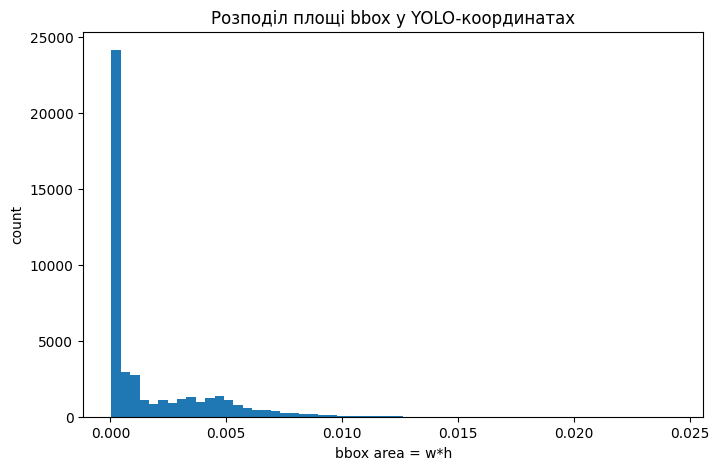

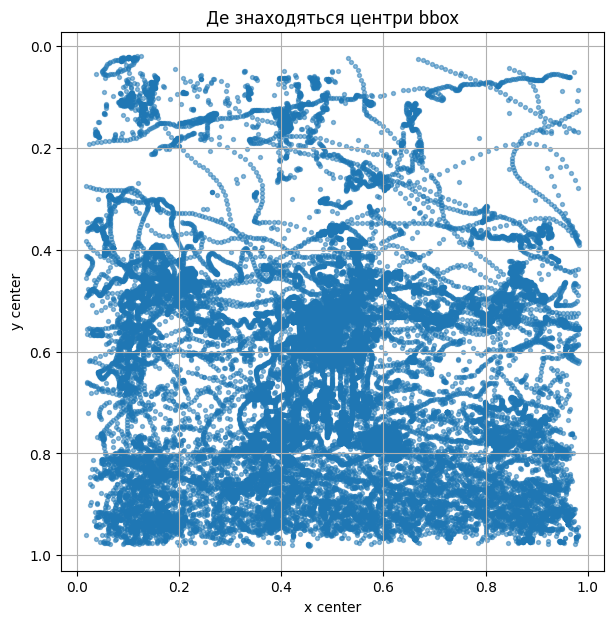

In [11]:
if len(object_df):
    plt.figure(figsize=(8, 5))
    plt.hist(object_df["area"], bins=60)
    plt.title("Розподіл площі bbox у YOLO-координатах")
    plt.xlabel("bbox area = w*h")
    plt.ylabel("count")
    plt.show()

    plt.figure(figsize=(7, 7))
    plt.scatter(object_df["x"], object_df["y"], s=8, alpha=0.5)
    plt.title("Де знаходяться центри bbox")
    plt.xlabel("x center")
    plt.ylabel("y center")
    plt.gca().invert_yaxis()
    plt.grid(True)
    plt.show()
else:
    print("Нема bbox для графіків.")


## 7. Перегляд підозрілих кадрів з bbox

Цей блок малює GT-бокси на підозрілих кадрах. Якщо тут видно хмари, HUD або бокс тільки на точці — такі label треба виправити.


train_clean_Infiray_2025-05-25T20-24-31Z_021794.jpg


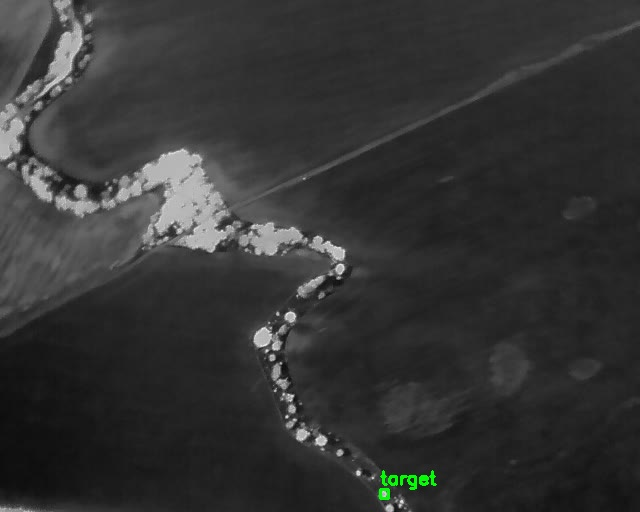

train_clean_Infiray_2025-05-25T20-24-31Z_021238.jpg


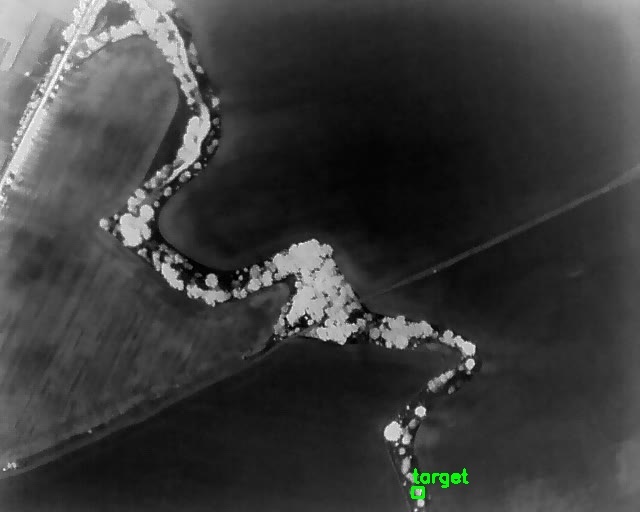

val_clean_Infiray_2025-06-09T22-12-37Z_038975.jpg


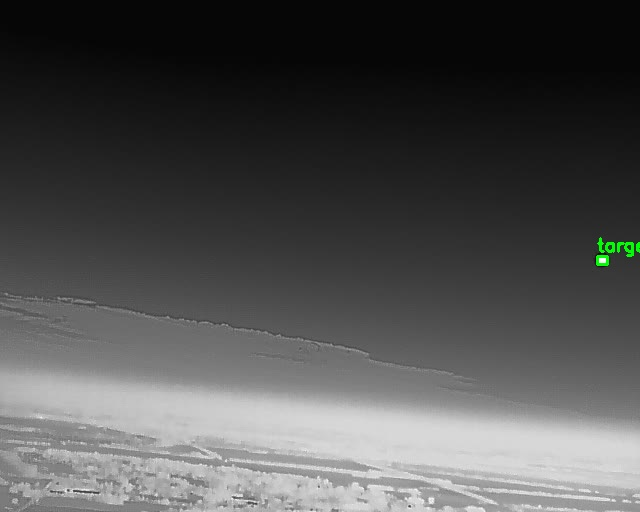

train_clean_Infiray_2025-06-08T20-53-52Z_003914.jpg


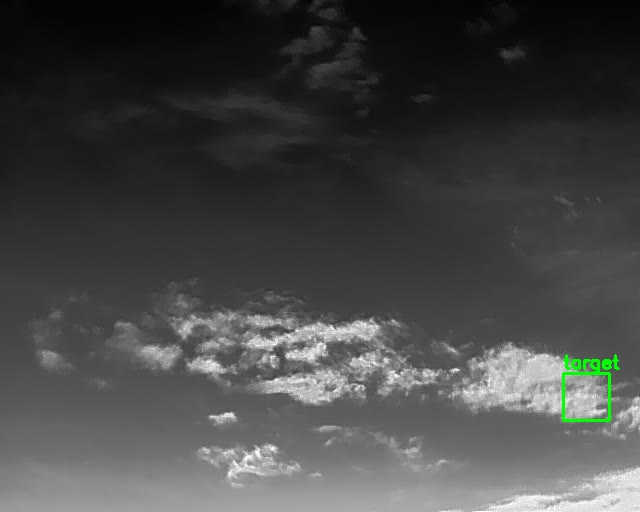

val_clean_Infiray_2025-07-18T19-21-08Z_003504.jpg


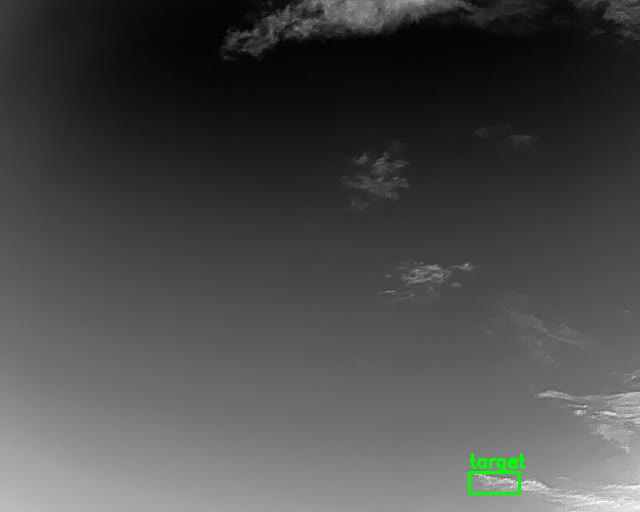

train_clean_Infiray_2025-06-08T20-53-52Z_004806.jpg


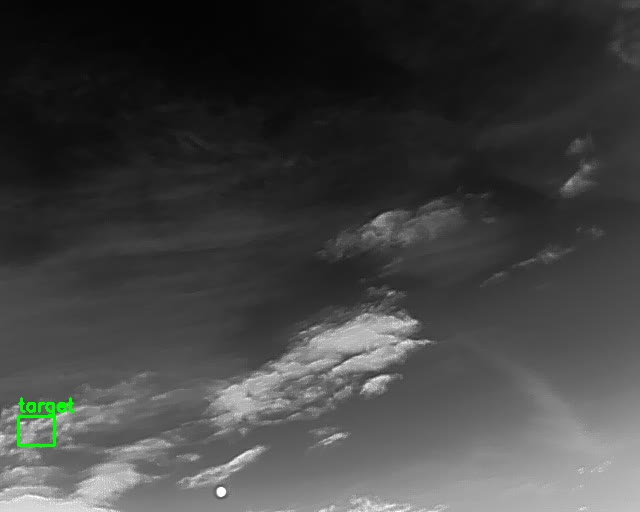

train_clean_Infiray_2025-06-08T20-53-52Z_036258.jpg


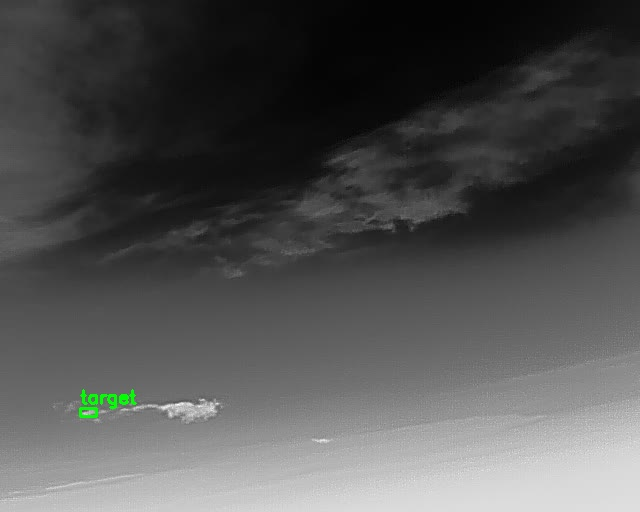

val_clean_Infiray_2025-07-18T19-21-08Z_032324.jpg


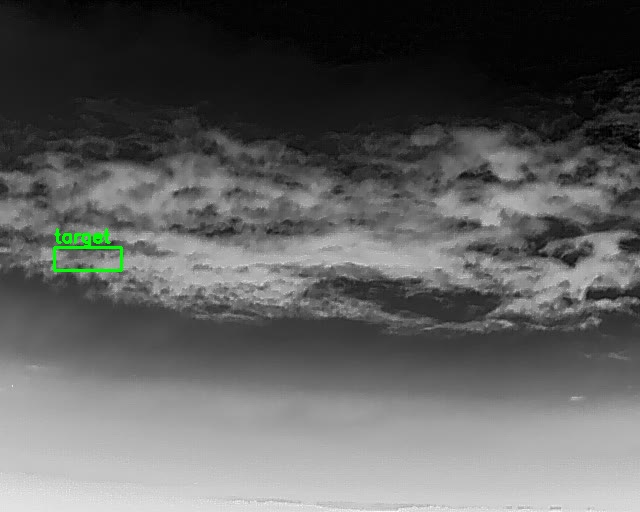

train_clean_Infiray_2025-06-08T20-53-52Z_005897.jpg


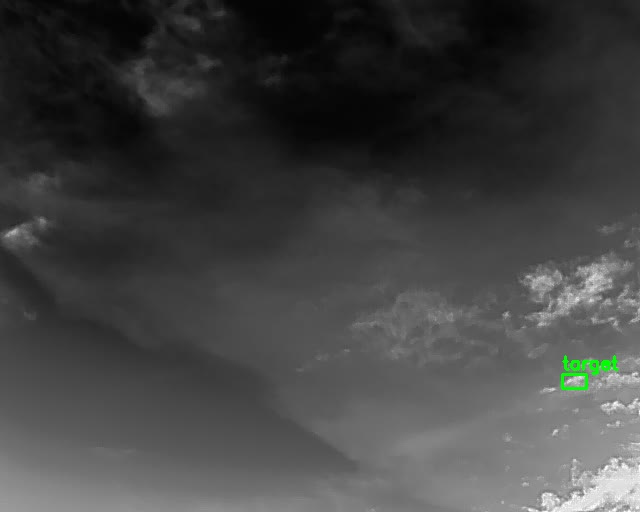

train_clean_Infiray_2025-06-08T20-53-52Z_001021.jpg


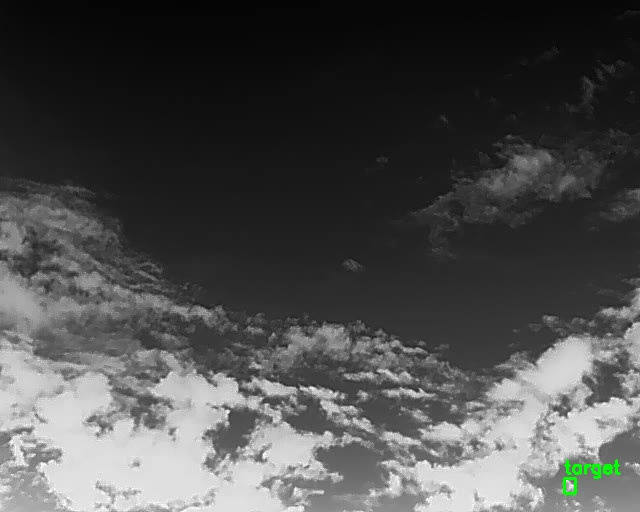

train_clean_Infiray_2025-06-08T20-53-52Z_013430.jpg


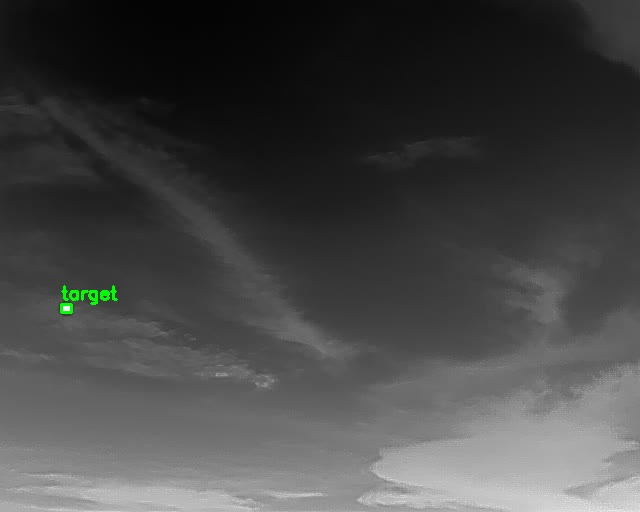

train_clean_Infiray_2025-06-08T20-53-52Z_019443.jpg


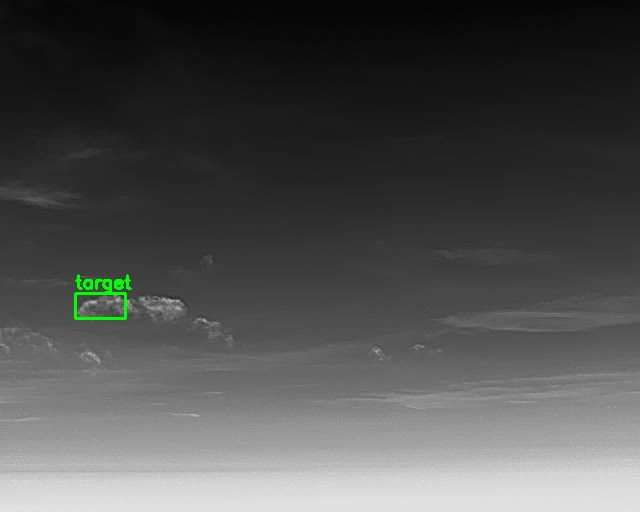

In [12]:
def draw_yolo_boxes(img_path: Path, label_path: Path, out_path: Path):
    img = cv2.imread(str(img_path))
    if img is None:
        return False
    h, w = img.shape[:2]
    objects, errors = parse_yolo_label(label_path)
    for obj in objects:
        xc, yc, bw, bh = obj["x"], obj["y"], obj["w"], obj["h"]
        x1 = int((xc - bw/2) * w)
        y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w)
        y2 = int((yc + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, CLASS_NAMES.get(obj["class"], str(obj["class"])), (x1, max(15, y1-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(out_path), img)
    return True

preview_dir = PROJECT_DIR / RUN_NAME / "dataset_audit_previews"
preview_dir.mkdir(parents=True, exist_ok=True)

if len(object_df):
    suspicious = object_df[
        (object_df["size_flag"].isin(["tiny", "huge"])) |
        (object_df["near_edge"]) |
        (object_df["in_hud_zone"])
    ].copy()

    show_df = suspicious if len(suspicious) else object_df
    show_df = show_df.sample(min(12, len(show_df)), random_state=SEED)

    for _, row in show_df.iterrows():
        img_path = Path(row["image_path"])
        split = row["split"]
        lbl_path = split_lbl_dir(split) / f"{img_path.stem}.txt"
        out_path = preview_dir / f"{split}_{img_path.name}"
        if draw_yolo_boxes(img_path, lbl_path, out_path):
            print(out_path.name)
            display(Image(filename=str(out_path)))
else:
    print("Нема bbox для перегляду.")


## 8. Clean/HUD/unknown аналіз

Якщо назви файлів або шлях містить `clean` чи `hud`, ноутбук окремо покаже статистику. Якщо все `unknown`, значить у назвах немає цієї інформації.


In [13]:
if len(image_df):
    group_report = image_df.groupby(["split", "group"]).agg(
        images=("image", "count"),
        negative_frames=("is_negative", "sum"),
        total_objects=("objects", "sum"),
    ).reset_index()
    group_report["negative_%"] = (group_report["negative_frames"] / group_report["images"] * 100).round(2)
    display(group_report)

if len(object_df):
    display(object_df.groupby(["split", "group", "size_flag"]).size().reset_index(name="bbox_count"))


,split,group,images,negative_frames,total_objects,negative_%
0,train,clean,31586,900,30686,2.85
1,val,clean,14301,300,14001,2.10


,split,group,size_flag,bbox_count
0,train,clean,normal,15336
1,train,clean,small,15350
2,val,clean,normal,11119
3,val,clean,small,2882


## 9. Перевірка можливого leakage між train і val

Якщо майже однакові кадри є і в `train`, і в `val`, метрики можуть бути завищені. Цей блок шукає дуже схожі кадри через простий image hash.


In [14]:
def average_hash(img_path: Path, size=8):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    avg = img.mean()
    bits = (img > avg).astype(np.uint8).flatten()
    return bits


def hamming(a, b):
    return int(np.count_nonzero(a != b))

if RUN_LEAKAGE_CHECK and {"train", "val"}.issubset(split_audits.keys()):
    train_imgs = split_audits["train"]["images"][:]
    val_imgs = split_audits["val"]["images"][:]
    random.shuffle(train_imgs)
    random.shuffle(val_imgs)
    train_imgs = train_imgs[:MAX_IMAGES_FOR_LEAKAGE]
    val_imgs = val_imgs[:MAX_IMAGES_FOR_LEAKAGE]

    print(f"Перевіряємо train={len(train_imgs)} проти val={len(val_imgs)}")

    train_hashes = []
    for p in tqdm(train_imgs, desc="hash train"):
        h = average_hash(p)
        if h is not None:
            train_hashes.append((p, h))

    val_hashes = []
    for p in tqdm(val_imgs, desc="hash val"):
        h = average_hash(p)
        if h is not None:
            val_hashes.append((p, h))

    leakage_rows = []
    for vp, vh in tqdm(val_hashes, desc="compare hashes"):
        for tp, th in train_hashes:
            d = hamming(vh, th)
            if d <= LEAKAGE_HASH_DISTANCE:
                leakage_rows.append({
                    "val_image": vp.name,
                    "train_image": tp.name,
                    "hash_distance": d,
                    "val_path": str(vp),
                    "train_path": str(tp),
                })
                break

    leakage_df = pd.DataFrame(leakage_rows)
    print("Можливих схожих train/val пар:", len(leakage_df))
    if len(leakage_df):
        display(leakage_df.head(50))
else:
    print("Leakage check пропущено.")


Leakage check пропущено.


## 10. Рекомендації перед навчанням

Цей блок не змінює датасет, а підказує, що варто виправити.


In [15]:
print("=== Автоматичні підказки ===")

if len(errors_df):
    print(f"- Є помилки у label-файлах: {len(errors_df)}. Спочатку виправ їх.")
else:
    print("- Формат label-файлів виглядає нормально.")

if len(image_df):
    report = image_df.groupby("split").agg(images=("image", "count"), neg=("is_negative", "sum"), obj=("objects", "sum"))
    for split, row in report.iterrows():
        neg_pct = row["neg"] / row["images"] * 100 if row["images"] else 0
        print(f"- {split}: negative frames = {neg_pct:.1f}%")
        if split == "train" and neg_pct < 5:
            print("  У train мало пустих кадрів. Модель може частіше ловити хмари/HUD як target.")
        if split == "train" and neg_pct > 45:
            print("  У train дуже багато пустих кадрів. Перевір, щоб positive frames теж було достатньо.")

if len(object_df):
    tiny_count = int((object_df["size_flag"] == "tiny").sum())
    hud_count = int(object_df["in_hud_zone"].sum())
    edge_count = int(object_df["near_edge"].sum())
    print(f"- tiny bbox: {tiny_count}")
    print(f"- bbox у HUD-зонах: {hud_count}")
    print(f"- bbox біля країв: {edge_count}")
    if tiny_count > 0:
        print("  Перевір tiny bbox: можливо, розмічена лише яскрава точка, а не весь об'єкт.")
    if hud_count > 0:
        print("  Перевір HUD bbox: можливо, модель навчиться ловити елементи інтерфейсу.")
else:
    print("- Об'єктів не знайдено. Навчання detection-моделі не має сенсу без positive labels.")


=== Автоматичні підказки ===
- Формат label-файлів виглядає нормально.
- train: negative frames = 2.8%
  У train мало пустих кадрів. Модель може частіше ловити хмари/HUD як target.
- val: negative frames = 2.1%
- tiny bbox: 0
- bbox у HUD-зонах: 12455
- bbox біля країв: 417
  Перевір HUD bbox: можливо, модель навчиться ловити елементи інтерфейсу.


In [16]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
CUDA device count: 1
GPU: NVIDIA GeForce GTX 1650 Ti


## 11. Навчання YOLOv8

Параметри нижче більш обережні для IR/монохромного відео:

- менше HSV-аугментацій;
- `imgsz=768` для дрібної цілі;
- `yolov8s.pt` як сильніший старт;
- помірний mosaic;
- patience більший, щоб модель не зупинилася зарано.


In [17]:
model = YOLO(BASE_MODEL)

train_results = model.train(
    data=str(dataset_yaml_path),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    workers=WORKERS,
    project=str(PROJECT_DIR),
    name=RUN_NAME,
    exist_ok=True,
    seed=SEED,

    save=True,
    plots=True,
    verbose=True,
    cache=False,
    patience=25,
    optimizer="auto",
    cos_lr=True,

    # Для IR/монохромного відео колірні аугментації робимо слабшими
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.10,

    # Геометрія: акуратно, щоб не ламати вигляд цілі
    degrees=0.0,
    translate=0.04,
    scale=0.25,
    shear=0.0,
    perspective=0.0,
    fliplr=0.5,
    flipud=0.0,

    # Mosaic корисний, але якщо ціль дуже маленька — не переборщувати
    mosaic=0.20,
    close_mosaic=10,
    mixup=0.0,
    copy_paste=0.0,
)

print("Навчання завершено.")


Ultralytics 8.4.52  Python-3.14.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce GTX 1650 Ti, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=e:\Drone\VideoDetection\v 0.2\yolo_split\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.2, multi_scale=0.0, name=target_detector_cpu_test, nbs=64, nms=False, opset=None, optimize=False

## 12. Де лежать результати


In [18]:
run_dir = PROJECT_DIR / RUN_NAME
weights_dir = run_dir / "weights"
best_model_path = weights_dir / "best.pt"
last_model_path = weights_dir / "last.pt"

print("RUN DIR   :", run_dir)
print("BEST MODEL:", best_model_path, "->", best_model_path.exists())
print("LAST MODEL:", last_model_path, "->", last_model_path.exists())

print("\nКорисні файли:")
for name in [
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "F1_curve.png",
    "P_curve.png",
    "PR_curve.png",
    "R_curve.png",
    "labels.jpg",
    "labels_correlogram.jpg",
]:
    p = run_dir / name
    print(f"{name:32} -> {p.exists()}")


RUN DIR   : e:\Drone\VideoDetection\v 0.2\runs\target_detector_cpu_test
BEST MODEL: e:\Drone\VideoDetection\v 0.2\runs\target_detector_cpu_test\weights\best.pt -> True
LAST MODEL: e:\Drone\VideoDetection\v 0.2\runs\target_detector_cpu_test\weights\last.pt -> True

Корисні файли:
results.png                      -> True
confusion_matrix.png             -> True
confusion_matrix_normalized.png  -> True
F1_curve.png                     -> False
P_curve.png                      -> False
PR_curve.png                     -> False
R_curve.png                      -> False
labels.jpg                       -> True
labels_correlogram.jpg           -> False


## 13. Показати графіки навчання



results.png


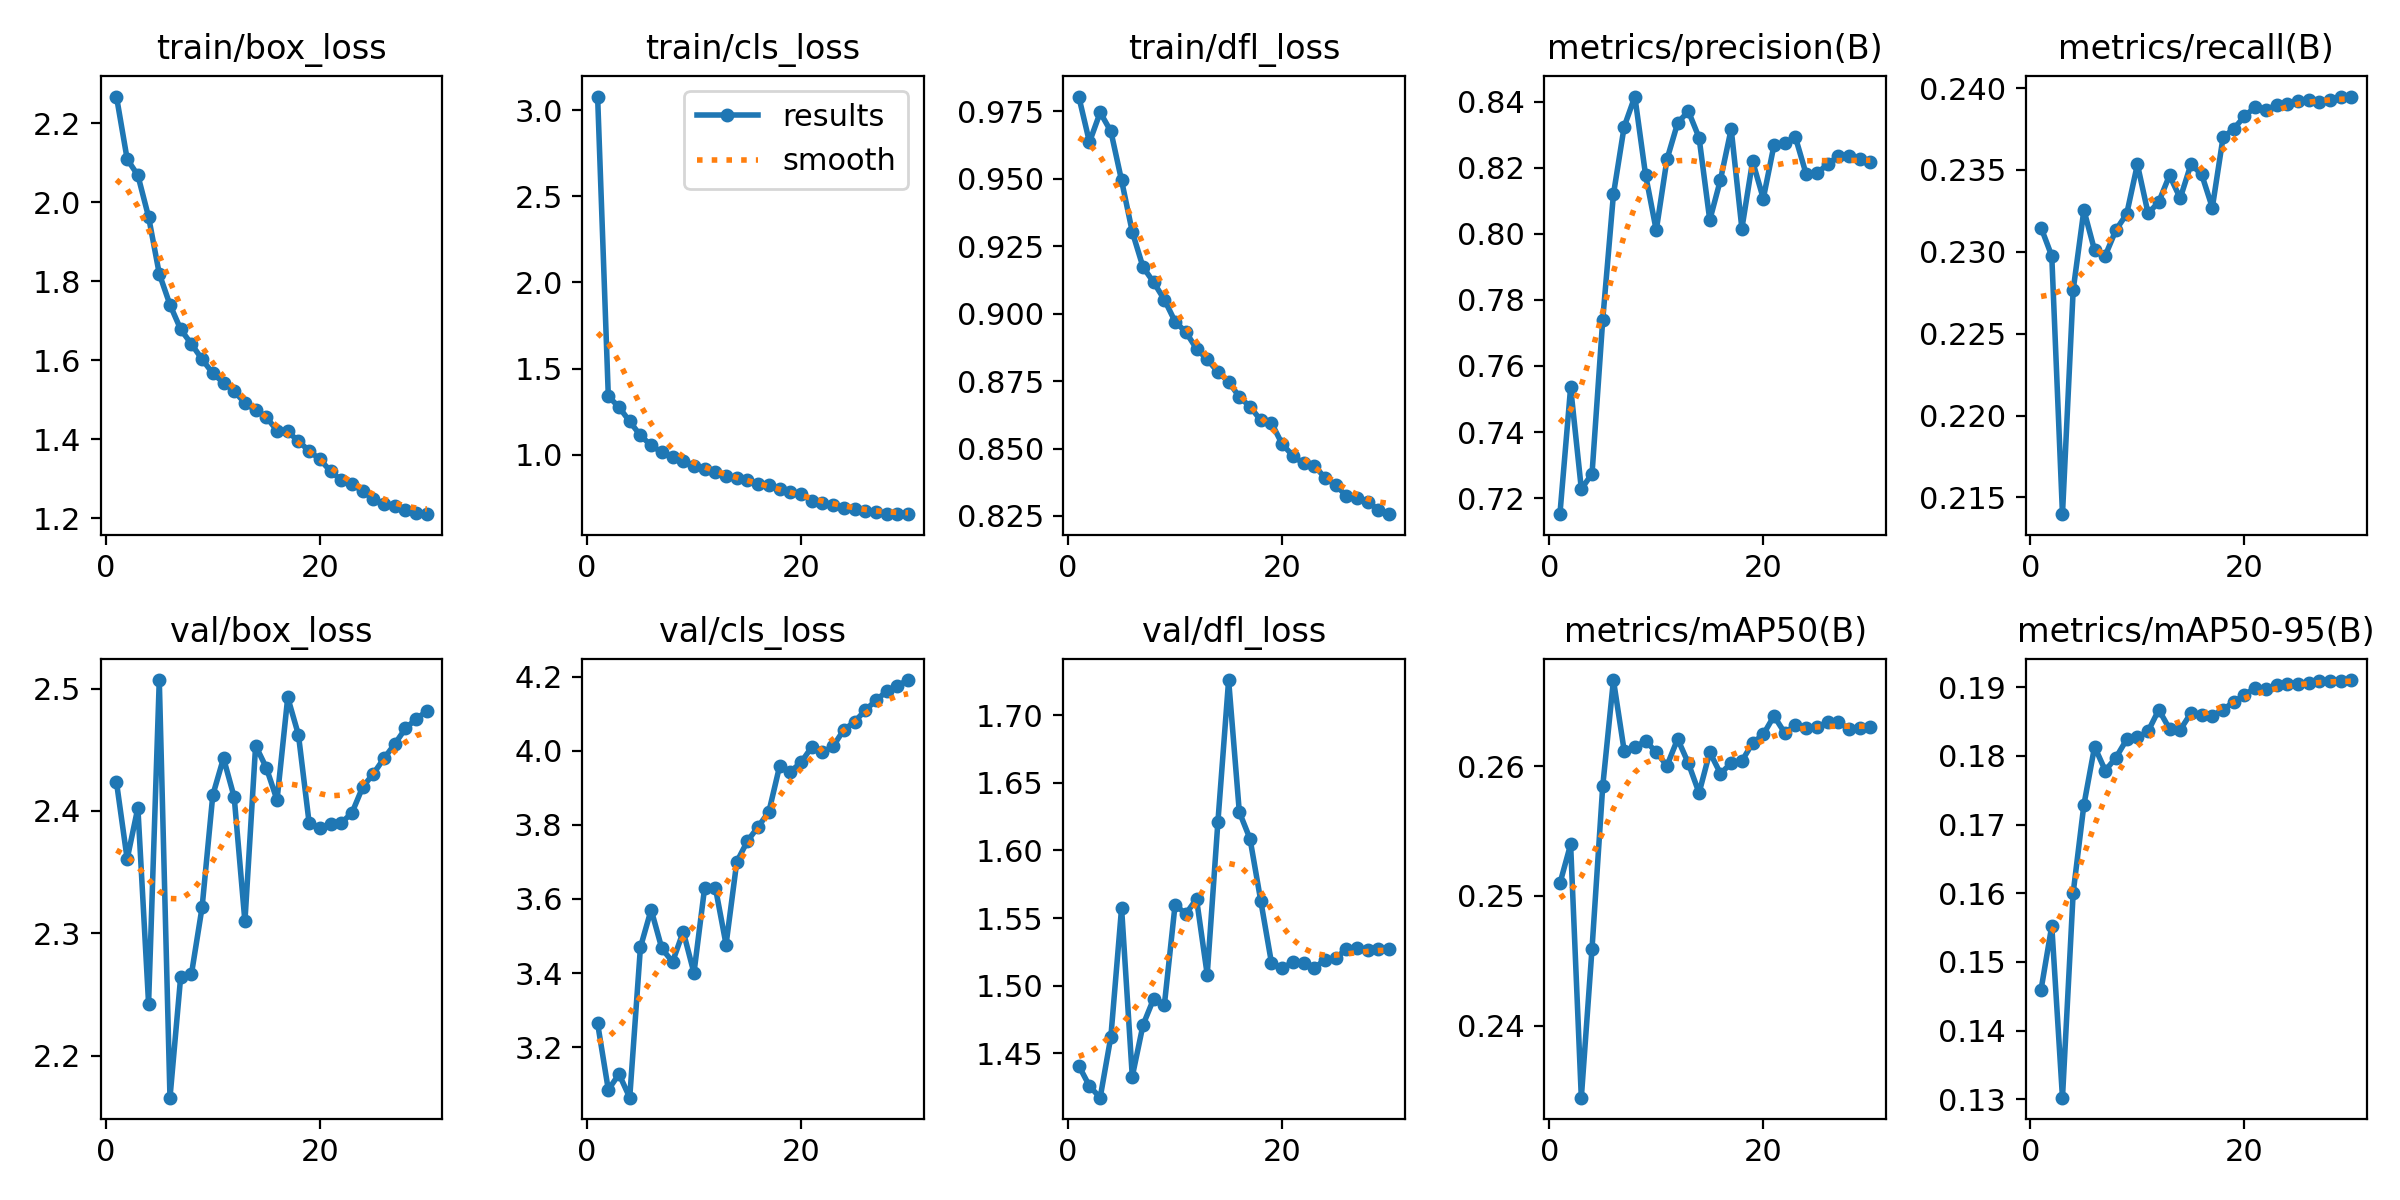


confusion_matrix.png


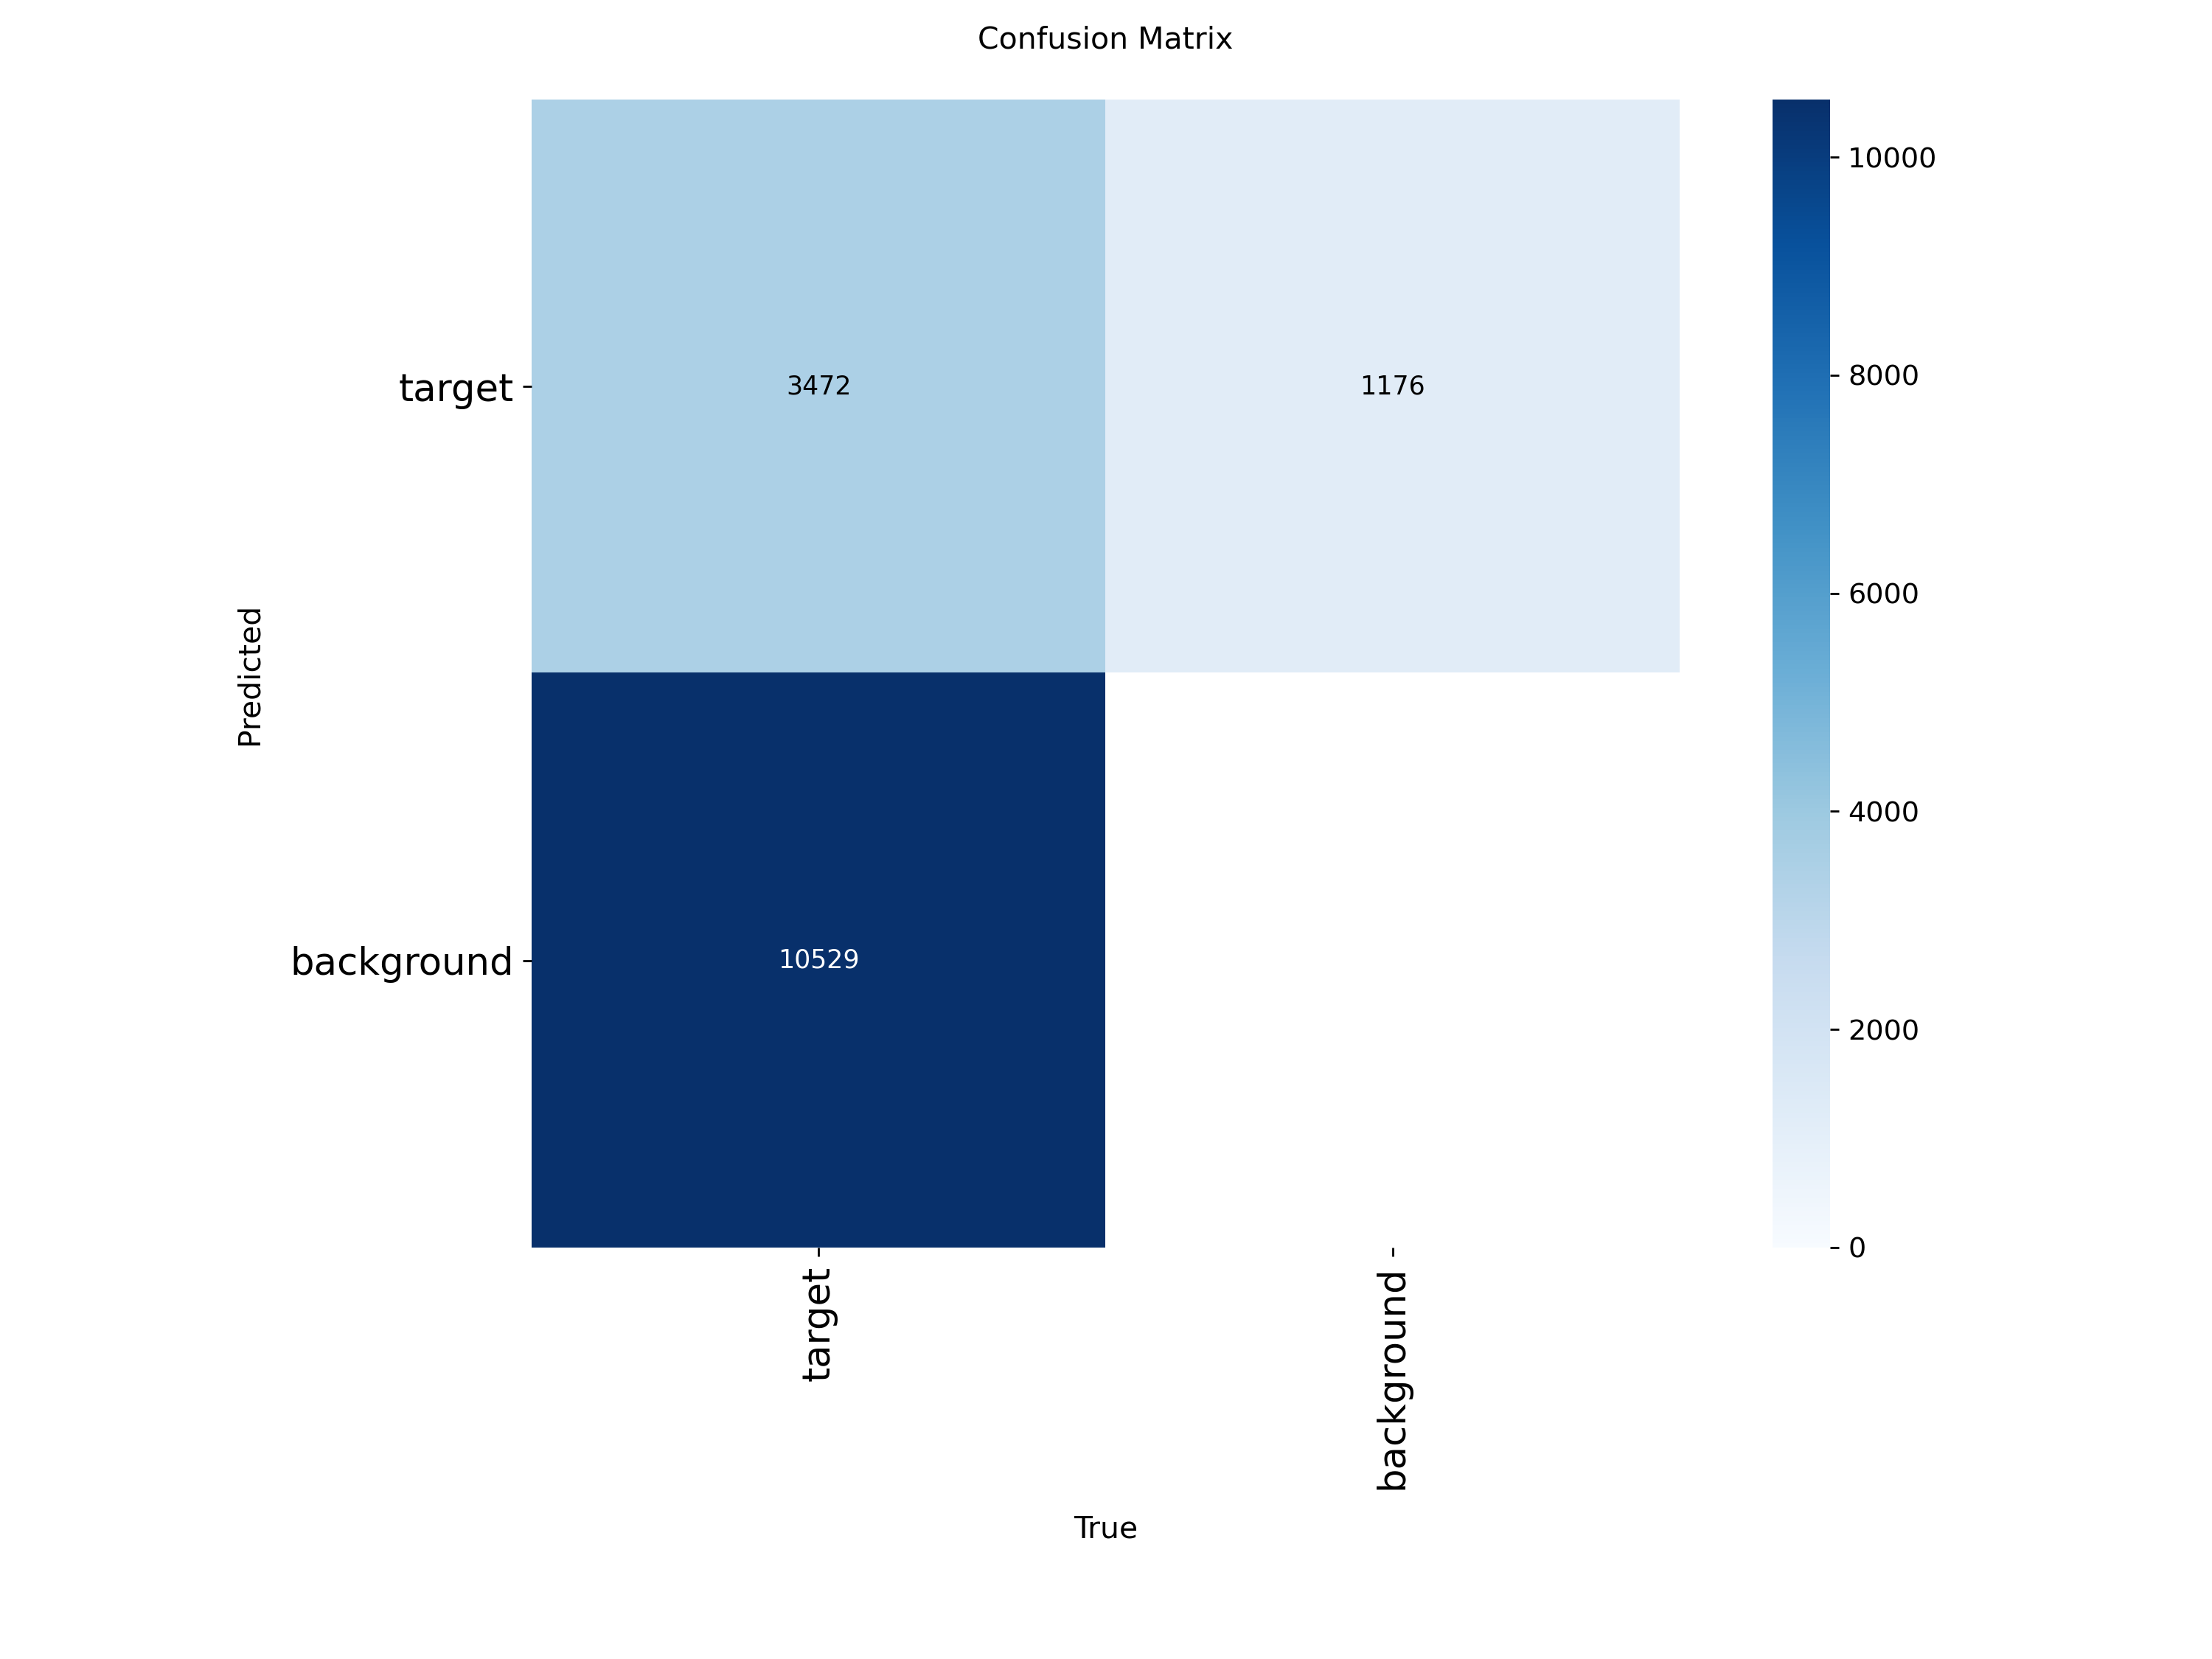


confusion_matrix_normalized.png


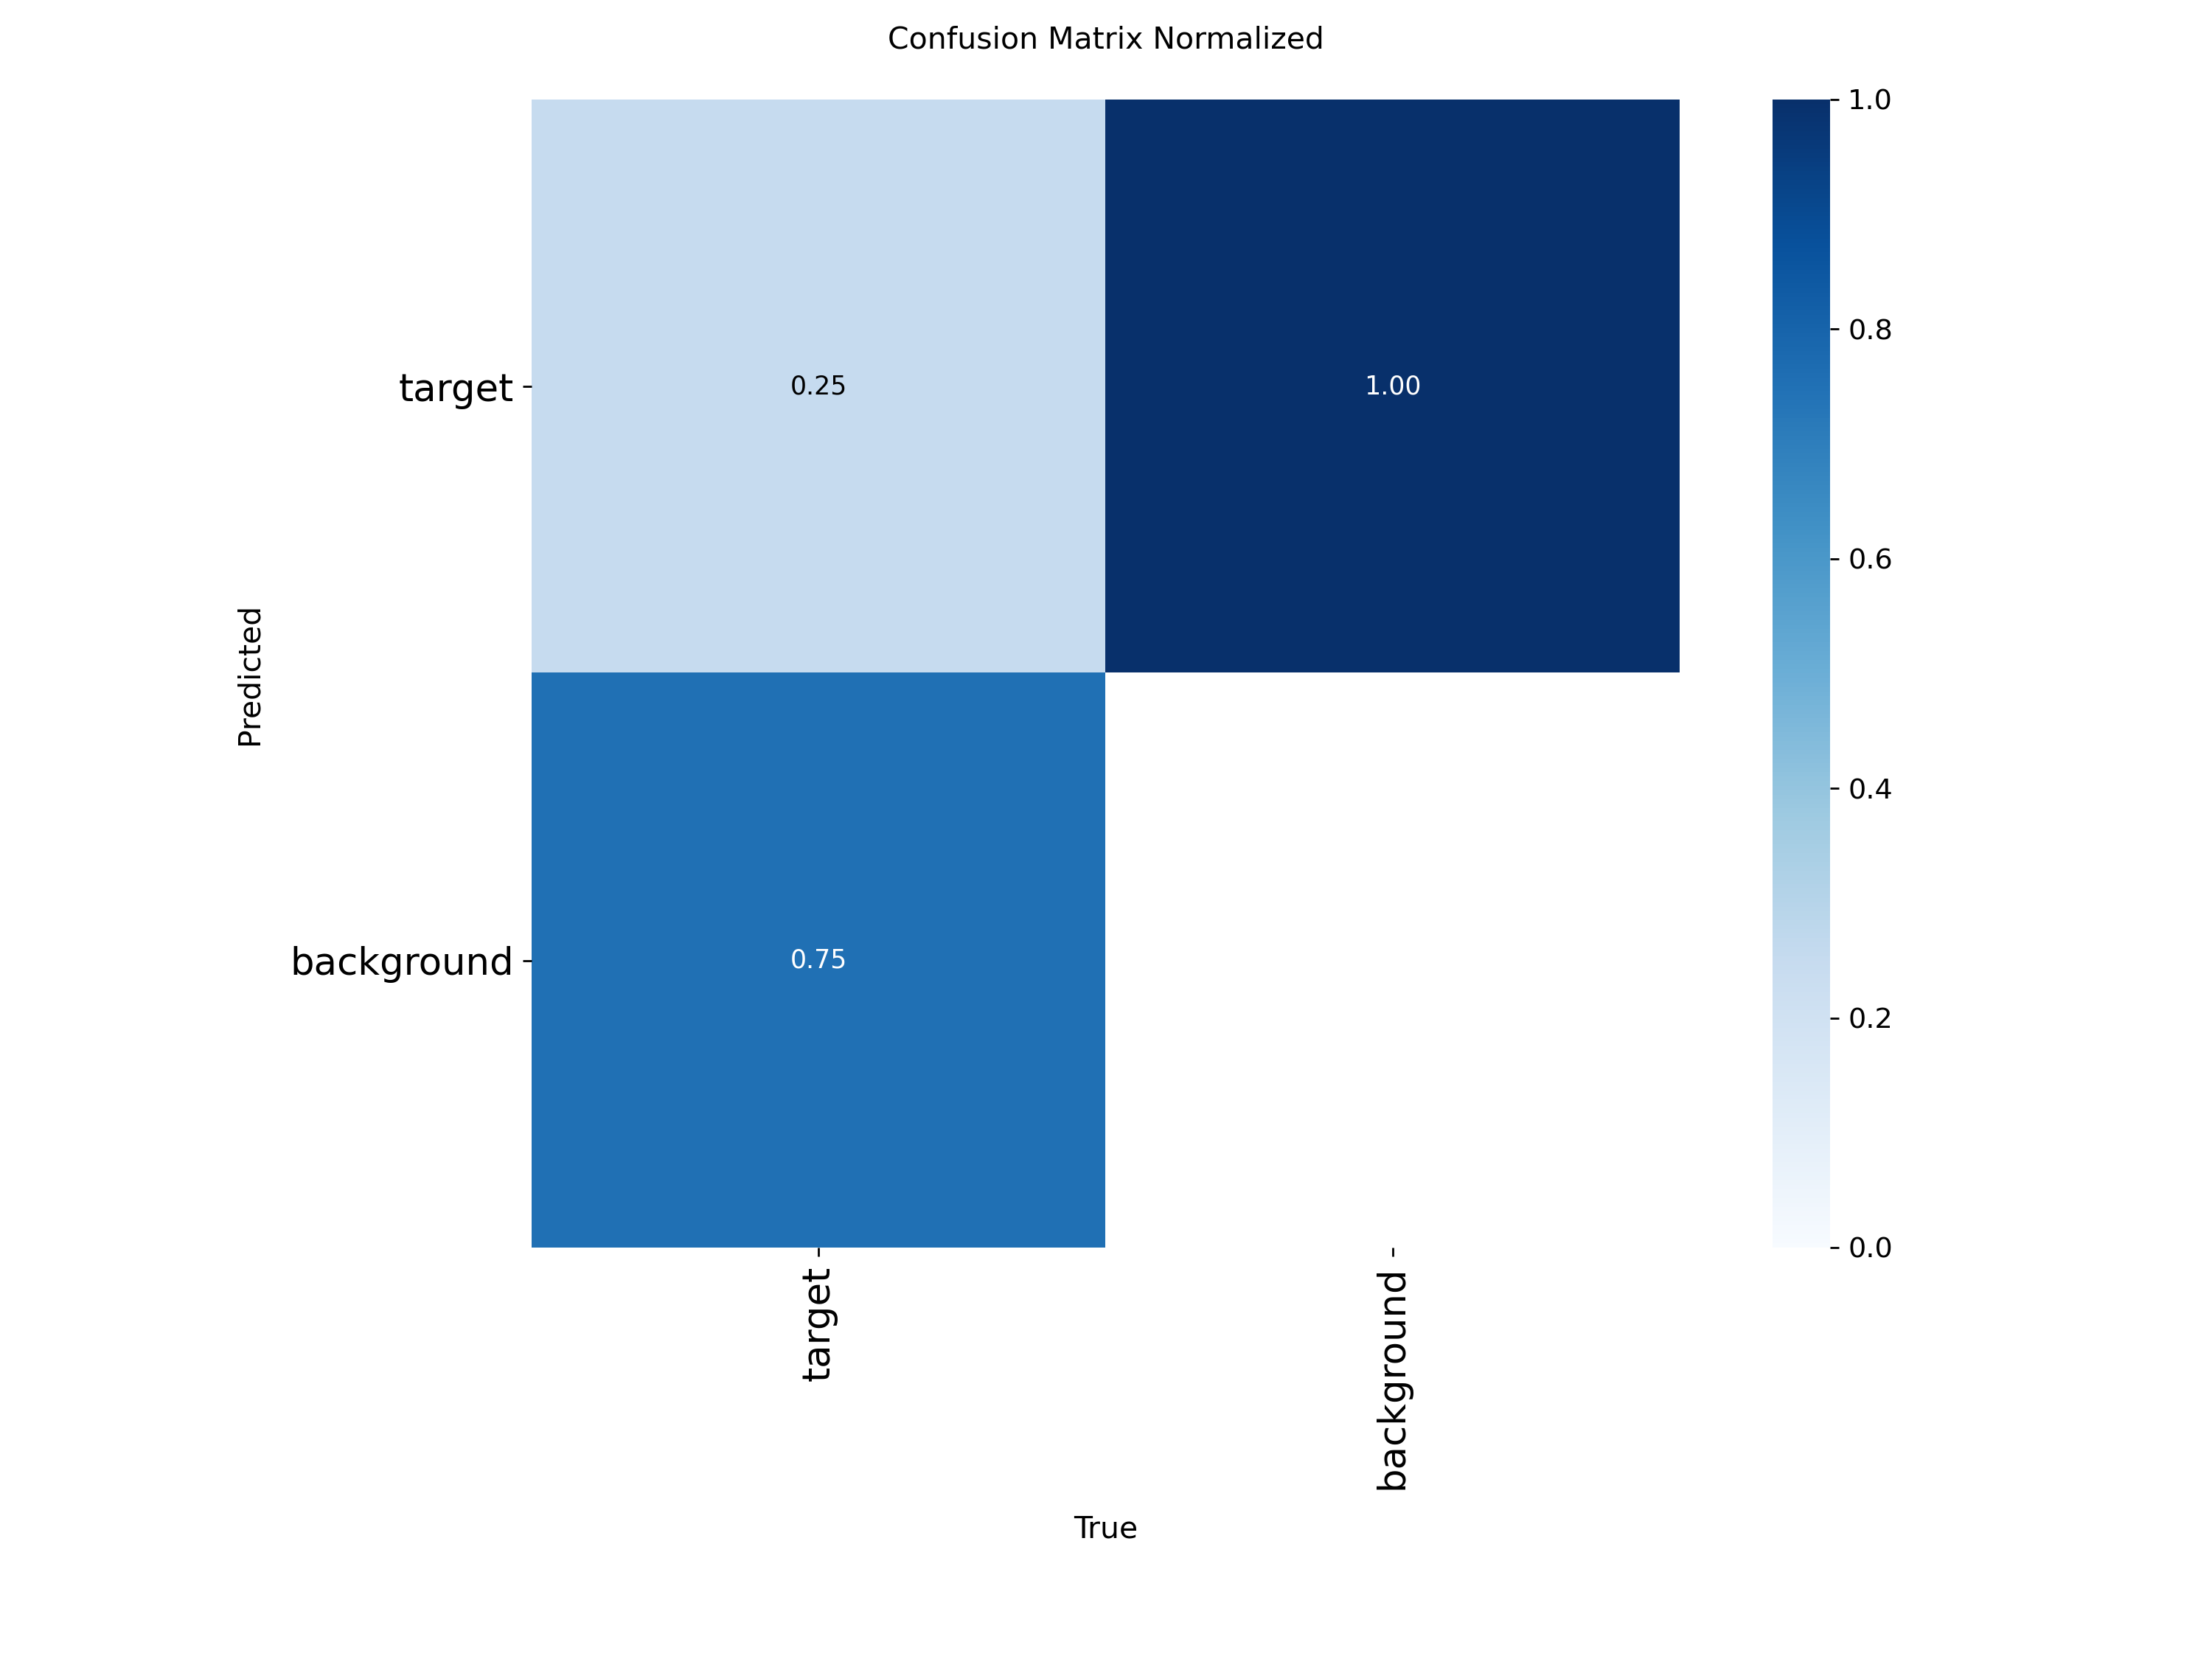


labels.jpg


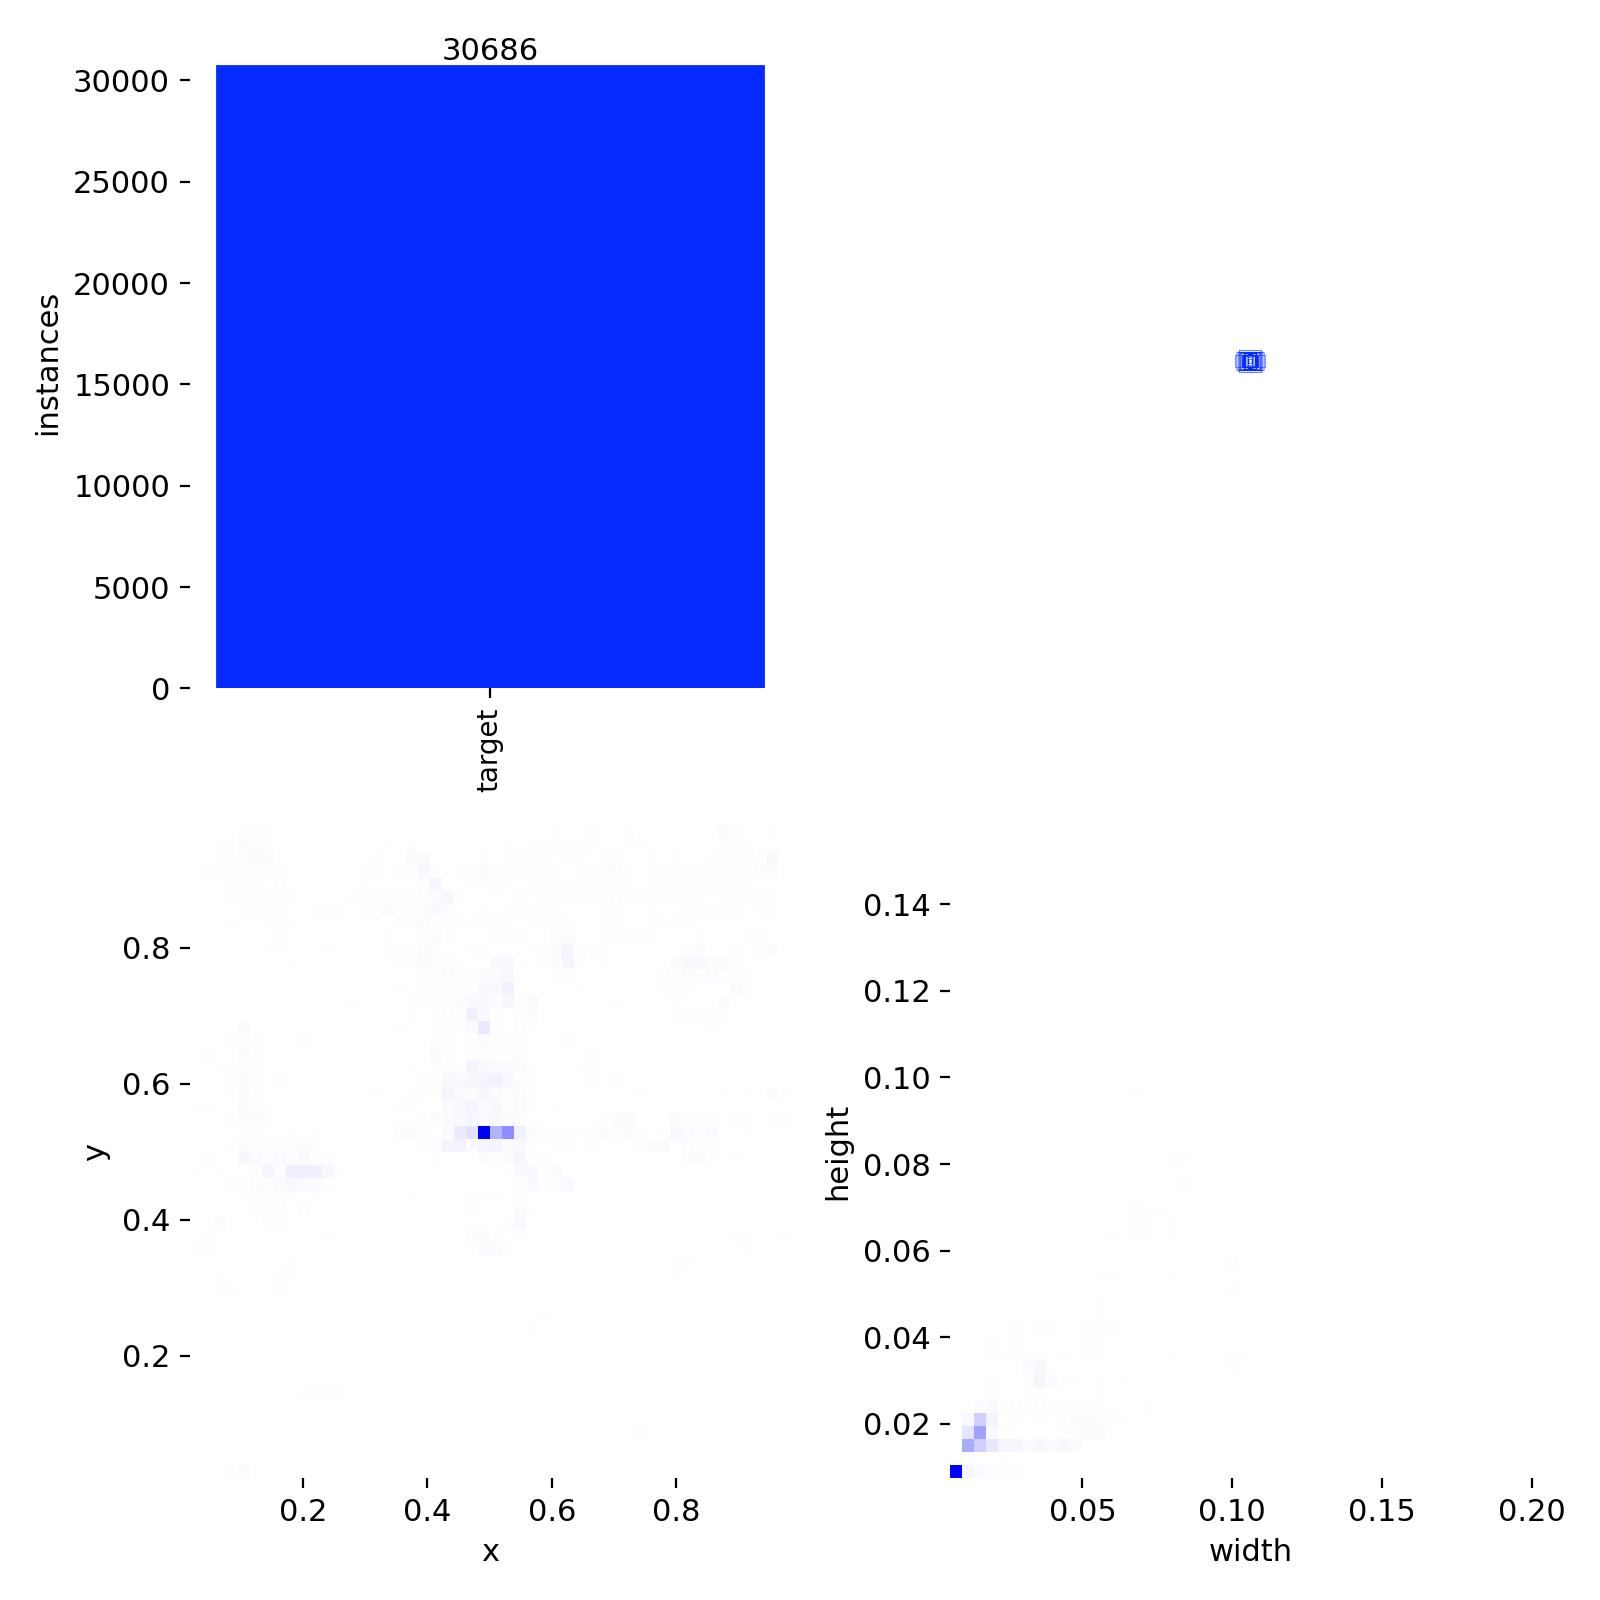

In [19]:
for name in [
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "PR_curve.png",
    "F1_curve.png",
    "labels.jpg",
]:
    p = run_dir / name
    if p.exists():
        print(f"\n{name}")
        display(Image(filename=str(p)))


## 14. Валідація моделі

`conf=0.001` для валідації — нормальна практика, щоб YOLO побудував повні криві precision/recall. Для реального prediction нижче буде окремий `conf`.


In [21]:
if not best_model_path.exists():
    raise FileNotFoundError("best.pt не знайдено. Спочатку запусти навчання.")

best_model = YOLO(str(best_model_path))

val_metrics = best_model.val(
    data=str(dataset_yaml_path),
    split="val",
    imgsz=IMGSZ,
    conf=0.001,
    iou=0.50,
    plots=True,
    project=str(PROJECT_DIR),
    name=f"{RUN_NAME}_val_metrics",
    exist_ok=True,

    workers=0,      # головне виправлення для Windows
    batch=4,        # можна 2 або 1, якщо знову вилітає
    cache=False,    # не вантажити все в RAM
    device=0,       # використовувати NVIDIA GPU
)

print("Валідація завершена.")
print(val_metrics)

Ultralytics 8.4.52  Python-3.14.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce GTX 1650 Ti, 4096MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 58.631.5 ms, read: 1.01.3 MB/s, size: 42.3 KB)
val: Scanning E:\Drone\VideoDetection\v 0.2\yolo_split\val\labels.cache... 14301 images, 300 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 14301/14301 200.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3576/3576 12.1it/s 4:56<0.1s
                   all      14301      14001      0.823      0.239      0.264      0.191
Speed: 0.4ms preprocess, 5.8ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to E:\Drone\VideoDetection\v 0.2\runs\target_detector_cpu_test_val_metrics
Валідація завершена.
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytic

In [5]:
from pathlib import Path

BASE_DIR = Path.cwd()
PROJECT_DIR = BASE_DIR / "runs"

print("BASE_DIR:", BASE_DIR)
print("PROJECT_DIR:", PROJECT_DIR)
print("runs існує:", PROJECT_DIR.exists())

best_files = list(PROJECT_DIR.rglob("best.pt"))

print("Знайдено best.pt:", len(best_files))

for p in best_files:
    print(p)

BASE_DIR: e:\Drone\VideoDetection\v 0.2
PROJECT_DIR: e:\Drone\VideoDetection\v 0.2\runs
runs існує: True
Знайдено best.pt: 2
e:\Drone\VideoDetection\v 0.2\runs\target_detector_fixed\weights\best.pt
e:\Drone\VideoDetection\v 0.2\runs\target_detector_cpu_test\weights\best.pt


## 15. Prediction на validation-картинках


In [6]:
from pathlib import Path
import gc
import torch
from ultralytics import YOLO

BASE_DIR = Path.cwd()

# Датасет у тебе на скріні саме такий:
DATASET_DIR = BASE_DIR / "yolo_split"
val_images_dir = DATASET_DIR / "val" / "images"

PROJECT_DIR = BASE_DIR / "runs"

# Беремо кращий/основний run
RUN_NAME = "target_detector_fixed"
best_model_path = PROJECT_DIR / RUN_NAME / "weights" / "best.pt"

IMGSZ = 640

print("BASE_DIR:", BASE_DIR)
print("val_images_dir:", val_images_dir)
print("best_model_path:", best_model_path)

if not val_images_dir.exists():
    raise FileNotFoundError(f"Папку val images не знайдено: {val_images_dir}")

if not best_model_path.exists():
    raise FileNotFoundError(f"best.pt не знайдено: {best_model_path}")

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA:", torch.cuda.get_device_name(0))
else:
    print("CUDA не доступна, буде CPU")

best_model = YOLO(str(best_model_path))

PRED_CONF = 0.20
PRED_IOU = 0.50

pred_name = f"{RUN_NAME}_val_predictions_conf_{str(PRED_CONF).replace('.', '_')}"

pred_results = best_model.predict(
    source=str(val_images_dir),
    imgsz=IMGSZ,
    conf=PRED_CONF,
    iou=PRED_IOU,

    save=True,
    save_txt=True,
    save_conf=True,

    project=str(PROJECT_DIR),
    name=pred_name,
    exist_ok=True,

    device=0 if torch.cuda.is_available() else "cpu",
    batch=1,
    stream=True,
    workers=0,
    verbose=False,
)

count = 0
for r in pred_results:
    count += 1
    if count % 100 == 0:
        print(f"Processed: {count}")

pred_dir = PROJECT_DIR / pred_name

print("Prediction results:", pred_dir)
print("Total processed:", count)

BASE_DIR: e:\Drone\VideoDetection\v 0.2
val_images_dir: e:\Drone\VideoDetection\v 0.2\yolo_split\val\images
best_model_path: e:\Drone\VideoDetection\v 0.2\runs\target_detector_fixed\weights\best.pt
CUDA: NVIDIA GeForce GTX 1650 Ti
Processed: 100
Processed: 200
Processed: 300
Processed: 400
Processed: 500
Processed: 600
Processed: 700
Processed: 800
Processed: 900
Processed: 1000
Processed: 1100
Processed: 1200
Processed: 1300
Processed: 1400
Processed: 1500
Processed: 1600
Processed: 1700
Processed: 1800
Processed: 1900
Processed: 2000
Processed: 2100
Processed: 2200
Processed: 2300
Processed: 2400
Processed: 2500
Processed: 2600
Processed: 2700
Processed: 2800
Processed: 2900
Processed: 3000
Processed: 3100
Processed: 3200
Processed: 3300
Processed: 3400
Processed: 3500
Processed: 3600
Processed: 3700
Processed: 3800
Processed: 3900
Processed: 4000
Processed: 4100
Processed: 4200
Processed: 4300
Processed: 4400
Processed: 4500
Processed: 4600
Processed: 4700
Processed: 4800
Processed:

pred_dir: e:\Drone\VideoDetection\v 0.2\runs\target_detector_fixed_val_predictions_conf_0_2
Папка існує: True
Кількість prediction-зображень: 14301
clean_Infiray_2025-07-18T19-21-08Z_039953.jpg


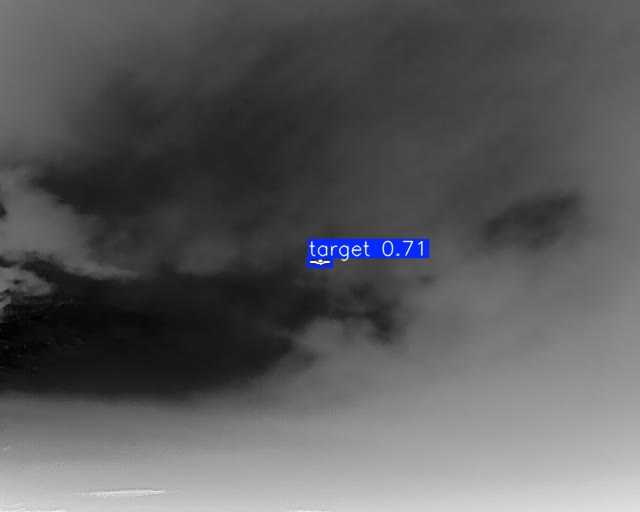

clean_Infiray_2025-06-09T19-14-26Z_011375.jpg


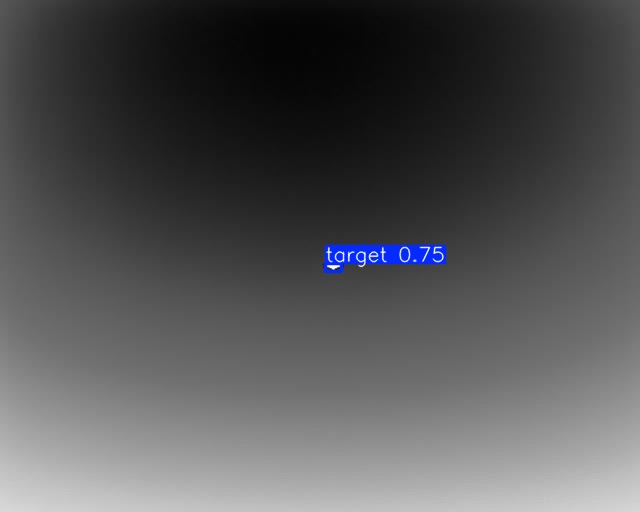

clean_Infiray_2025-06-09T22-12-37Z_007908.jpg


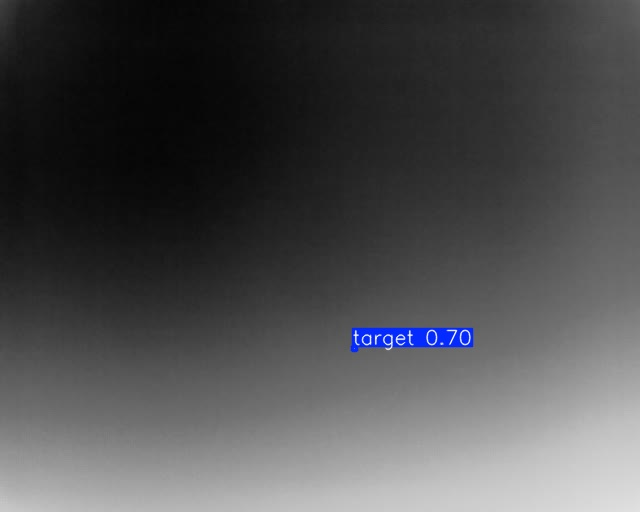

clean_Infiray_2025-06-09T22-12-37Z_038382.jpg


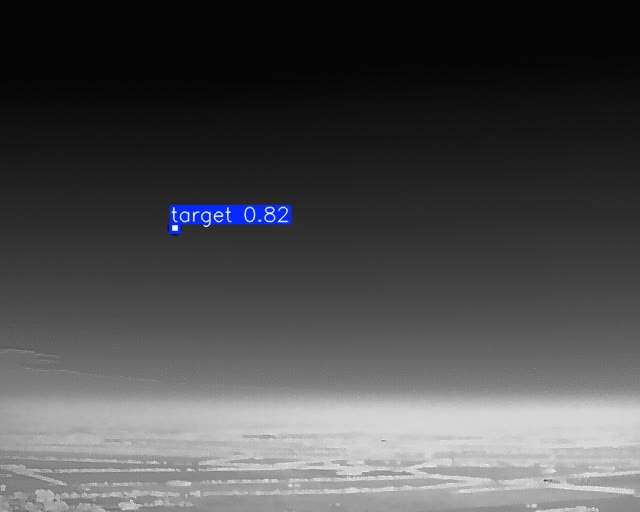

clean_Infiray_2025-07-18T19-21-08Z_033156.jpg


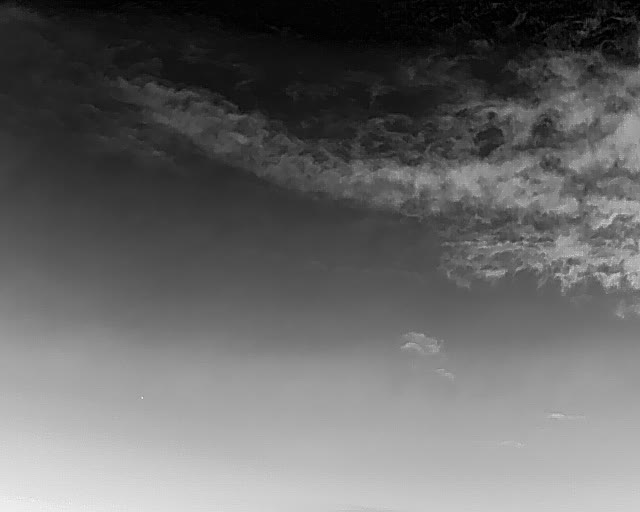

clean_Infiray_2025-06-09T22-12-37Z_037638.jpg


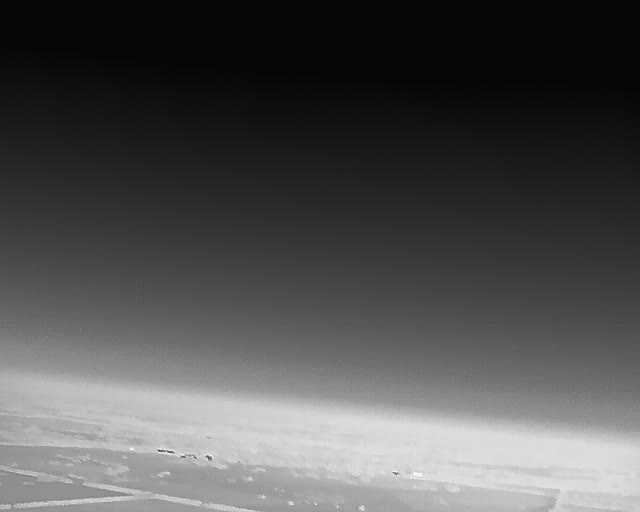

clean_Infiray_2025-07-18T19-21-08Z_038393.jpg


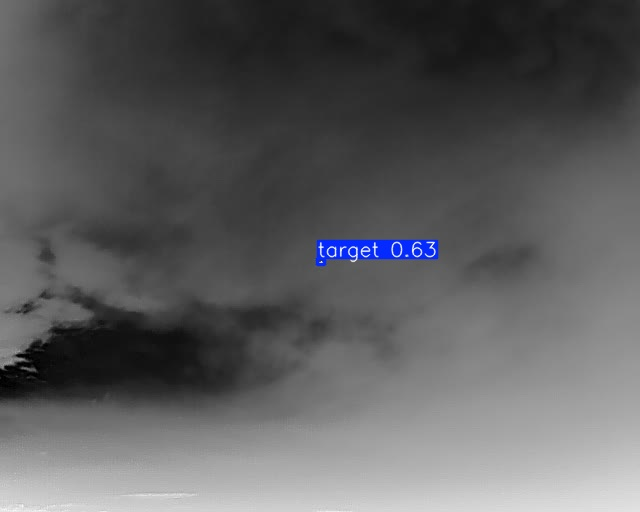

clean_Infiray_2025-07-18T19-21-08Z_024940.jpg


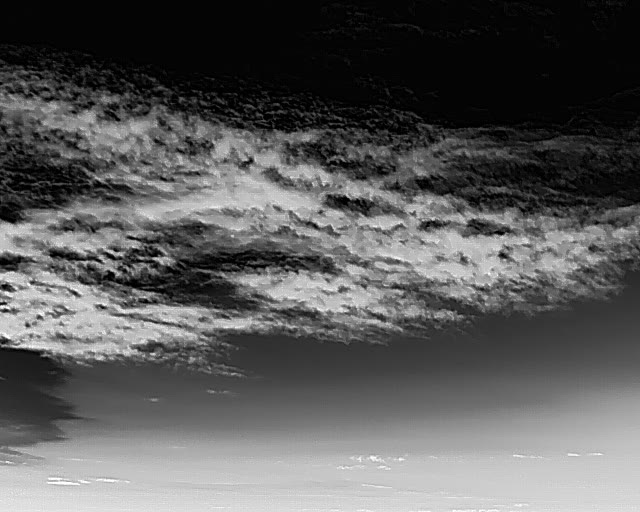

clean_Infiray_2025-07-18T19-21-08Z_021899.jpg


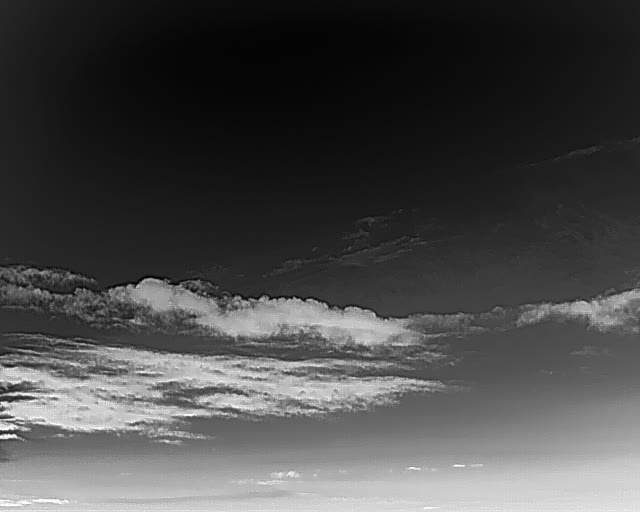

clean_Infiray_2025-06-09T22-12-37Z_038617.jpg


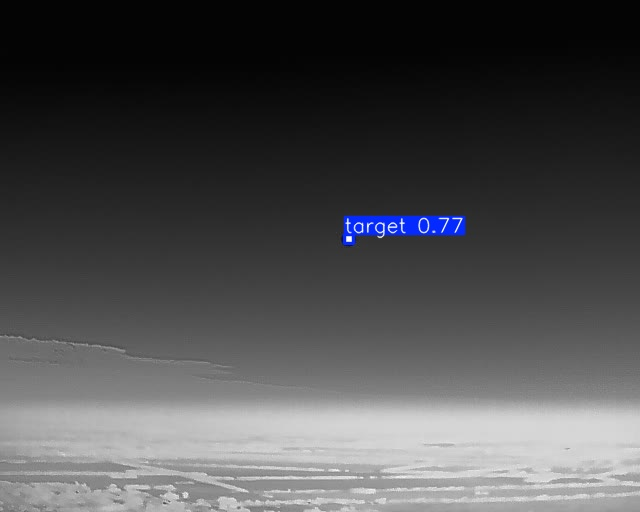

clean_Infiray_2025-07-18T19-21-08Z_032498.jpg


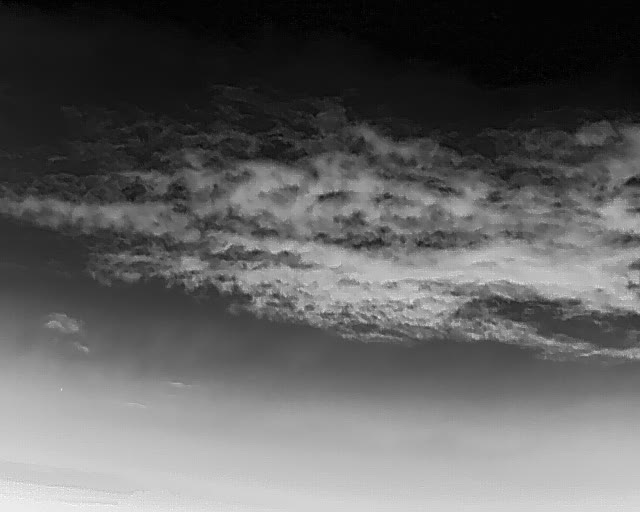

clean_Infiray_2025-06-09T22-12-37Z_016487.jpg


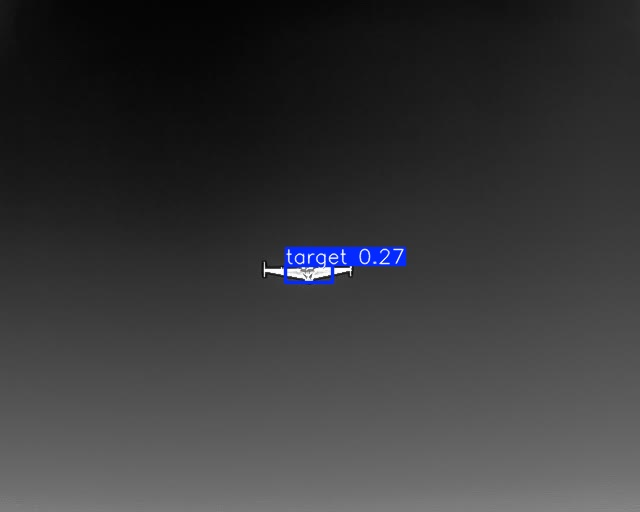

In [8]:
from pathlib import Path
import random
from IPython.display import Image, display

# формати картинок
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

BASE_DIR = Path.cwd()
PROJECT_DIR = BASE_DIR / "runs"

# ВАРІАНТ 1: якщо predict робила на всьому val
pred_dir = PROJECT_DIR / "target_detector_fixed_val_predictions_conf_0_2"

# ВАРІАНТ 2: якщо predict робила на sample, закоментуй верхній рядок і розкоментуй цей:
# pred_dir = PROJECT_DIR / "target_detector_fixed_sample_predictions_conf_0_2"

print("pred_dir:", pred_dir)
print("Папка існує:", pred_dir.exists())

pred_images = [
    p for p in pred_dir.iterdir()
    if p.is_file() and p.suffix.lower() in IMG_EXTS
] if pred_dir.exists() else []

print("Кількість prediction-зображень:", len(pred_images))

sample_count = min(12, len(pred_images))

if sample_count == 0:
    print("Немає зображень для показу. Можливо, pred_dir неправильний або predict ще не створив картинки.")
else:
    for p in random.sample(pred_images, sample_count):
        print(p.name)
        display(Image(filename=str(p)))

## 16. Prediction з різними confidence

In [10]:
from pathlib import Path
import gc
import torch

CONF_LEVELS = [0.10, 0.20, 0.30, 0.40]

for conf in CONF_LEVELS:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    name = f"{RUN_NAME}_val_predictions_conf_{str(conf).replace('.', '_')}"

    print(f"\n=== Start conf={conf} ===")

    results = best_model.predict(
        source=str(val_images_dir),
        imgsz=IMGSZ,
        conf=conf,
        iou=0.50,

        save=True,
        save_txt=False,
        save_conf=False,

        project=str(PROJECT_DIR),
        name=name,
        exist_ok=True,

        device=0 if torch.cuda.is_available() else "cpu",
        batch=1,
        stream=True,     # ОБОВʼЯЗКОВО, щоб не забивало RAM
        workers=0,       # для Windows
        verbose=False,
    )

    count = 0
    for r in results:
        count += 1
        if count % 100 == 0:
            print(f"conf={conf}: processed {count}")

    print(f"conf={conf} -> {PROJECT_DIR / name}")
    print(f"processed total: {count}")

    del results
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


=== Start conf=0.1 ===
conf=0.1: processed 100
conf=0.1: processed 200
conf=0.1: processed 300
conf=0.1: processed 400
conf=0.1: processed 500
conf=0.1: processed 600
conf=0.1: processed 700
conf=0.1: processed 800
conf=0.1: processed 900
conf=0.1: processed 1000
conf=0.1: processed 1100
conf=0.1: processed 1200
conf=0.1: processed 1300
conf=0.1: processed 1400
conf=0.1: processed 1500
conf=0.1: processed 1600
conf=0.1: processed 1700
conf=0.1: processed 1800
conf=0.1: processed 1900
conf=0.1: processed 2000
conf=0.1: processed 2100
conf=0.1: processed 2200
conf=0.1: processed 2300
conf=0.1: processed 2400
conf=0.1: processed 2500
conf=0.1: processed 2600
conf=0.1: processed 2700
conf=0.1: processed 2800
conf=0.1: processed 2900
conf=0.1: processed 3000
conf=0.1: processed 3100
conf=0.1: processed 3200
conf=0.1: processed 3300
conf=0.1: processed 3400
conf=0.1: processed 3500
conf=0.1: processed 3600
conf=0.1: processed 3700
conf=0.1: processed 3800
conf=0.1: processed 3900
conf=0.1: 

## 17. Необов'язково: прогін по відео

Увімкни `RUN_VIDEO_PREDICT = True` в налаштуваннях і вкажи `VIDEO_PATH`.


In [ ]:
from pathlib import Path
import cv2
import torch
from ultralytics import YOLO
import gc

# =========================
# НАЛАШТУВАННЯ
# =========================

BASE_DIR = Path.cwd().resolve()

# Пошук моделі best.pt у можливих місцях
possible_model_paths = [
    BASE_DIR / "fly-control" / "models" / "best.pt",
    BASE_DIR.parent / "fly-control" / "models" / "best.pt",
    BASE_DIR / "models" / "best.pt",
]

best_model_path = None

for path in possible_model_paths:
    if path.exists():
        best_model_path = path
        break

if best_model_path is None:
    checked_paths = "\n".join(str(p) for p in possible_model_paths)
    raise FileNotFoundError(
        "best.pt не знайдено.\n"
        "Перевір, що модель лежить у fly-control/models/best.pt\n\n"
        f"Перевірені шляхи:\n{checked_paths}"
    )

# Пошук тестового відео
possible_video_paths = [
    BASE_DIR / "videos" / "test_video.avi",
    BASE_DIR.parent / "videos" / "test_video.avi",
    BASE_DIR / "test_video.avi",
]

VIDEO_PATH = None

for path in possible_video_paths:
    if path.exists():
        VIDEO_PATH = path
        break

if VIDEO_PATH is None:
    checked_paths = "\n".join(str(p) for p in possible_video_paths)
    raise FileNotFoundError(
        "Тестове відео не знайдено.\n"
        "Перевір, що файл test_video.avi лежить у папці videos.\n\n"
        f"Перевірені шляхи:\n{checked_paths}"
    )

IMGSZ = 640
CONF = 0.20
IOU = 0.50

DISPLAY_WIDTH = 960
SAVE_OUTPUT = False

OUTPUT_DIR = BASE_DIR / "outputs"

print("BASE_DIR:", BASE_DIR)
print("Модель знайдена:", best_model_path)
print("Відео знайдено:", VIDEO_PATH)

# =========================
# ПЕРЕВІРКИ ТА ЗАВАНТАЖЕННЯ МОДЕЛІ
# =========================

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    DEVICE = 0
    print("CUDA:", torch.cuda.get_device_name(0))
else:
    DEVICE = "cpu"
    print("CUDA не доступна, буде CPU")

model = YOLO(str(best_model_path))

print("Модель завантажена:", best_model_path)

# =========================
# ВІДКРИТТЯ ВІДЕО
# =========================

cap = cv2.VideoCapture(str(VIDEO_PATH))

if not cap.isOpened():
    raise RuntimeError(f"Не вдалося відкрити відео: {VIDEO_PATH}")

fps = cap.get(cv2.CAP_PROP_FPS)

if fps <= 0:
    fps = 25

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("FPS:", fps)
print("Кількість кадрів:", frame_count)

# =========================
# ЗБЕРЕЖЕННЯ, ЯКЩО ТРЕБА
# =========================

writer = None

if SAVE_OUTPUT:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    out_path = OUTPUT_DIR / f"{VIDEO_PATH.stem}_detected.avi"

    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*"MJPG")

    writer = cv2.VideoWriter(
        str(out_path),
        fourcc,
        fps,
        (frame_width, frame_height)
    )

    print("Відео буде збережено:", out_path)

# =========================
# REAL-TIME DETECTION
# =========================

cv2.namedWindow("YOLO realtime detection", cv2.WINDOW_NORMAL)

frame_idx = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    frame_idx += 1

    results = model.predict(
        source=frame,
        imgsz=IMGSZ,
        conf=CONF,
        iou=IOU,
        device=DEVICE,
        verbose=False
    )

    annotated_frame = results[0].plot()

    # Збереження повного кадру
    if writer is not None:
        writer.write(annotated_frame)

    # Масштабування тільки для показу
    h, w = annotated_frame.shape[:2]

    scale = DISPLAY_WIDTH / w
    display_h = int(h * scale)

    display_frame = cv2.resize(
        annotated_frame,
        (DISPLAY_WIDTH, display_h)
    )

    text = f"Frame: {frame_idx}/{frame_count} | conf={CONF}"

    cv2.putText(
        display_frame,
        text,
        (20, 35),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )

    cv2.imshow("YOLO realtime detection", display_frame)

    # q — вийти
    # space — пауза
    key = cv2.waitKey(1) & 0xFF

    if key == ord("q"):
        break

    if key == ord(" "):
        cv2.waitKey(0)

cap.release()

if writer is not None:
    writer.release()

cv2.destroyAllWindows()

print("Готово.")

BASE_DIR: /home/quritt/Documents/dip/fly_object_detection/target-detection-CV
Модель знайдена: /home/quritt/Documents/dip/fly_object_detection/fly-control/models/best.pt
Відео знайдено: /home/quritt/Documents/dip/fly_object_detection/videos/test_video.avi
CUDA не доступна, буде CPU
Модель завантажена: /home/quritt/Documents/dip/fly_object_detection/fly-control/models/best.pt
FPS: 50.0
Кількість кадрів: 0


QFontDatabase: Cannot find font directory /home/quritt/Documents/dip/fly_object_detection/.venv/lib64/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/quritt/Documents/dip/fly_object_detection/.venv/lib64/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/quritt/Documents/dip/fly_object_detection/.venv/lib64/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/quritt/Documents/dip/fly_object_detection/.venv/lib64/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://de

## 18. Як читати результат

Орієнтир:

- **низький recall** → модель пропускає ціль;
- **низький precision** → модель ловить хмари, HUD, шум;
- **mAP нормальний, але візуально погано** → найімовірніше проблема в розмітці або leakage;
- **бокс тільки на яскравій точці** → треба виправляти bbox в датасеті;
- **добре на clean, погано на HUD** → треба більше HUD-negative кадрів і чистити HUD-помилкові labels;
- **далекі цілі не бачить** → збільшити `imgsz`, додати більше далеких прикладів, не робити bbox надто мікроскопічним.


In [5]:
from pathlib import Path

BASE_DIR = Path.cwd()
PROJECT_DIR = BASE_DIR / "runs"

RUN_NAME = "target_detector_fixed"
best_model_path = PROJECT_DIR / RUN_NAME / "weights" / "best.pt"

pred_dir = PROJECT_DIR / f"{RUN_NAME}_val_predictions_conf_0_2"

print("Блокнот завершено.")
print("Основна папка запуску:", PROJECT_DIR)
print("Назва запуску:", RUN_NAME)
print("Найкраща модель:", best_model_path)
print("Prediction на val:", pred_dir)

print("best.pt існує:", best_model_path.exists())
print("prediction-папка існує:", pred_dir.exists())

Блокнот завершено.
Основна папка запуску: e:\Drone\VideoDetection\v 0.2\runs
Назва запуску: target_detector_fixed
Найкраща модель: e:\Drone\VideoDetection\v 0.2\runs\target_detector_fixed\weights\best.pt
Prediction на val: e:\Drone\VideoDetection\v 0.2\runs\target_detector_fixed_val_predictions_conf_0_2
best.pt існує: True
prediction-папка існує: True
